<a href="https://colab.research.google.com/github/Mario-Cattaneo/SemesterProject/blob/main/Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Imports and Device Setup
import copy
import math
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cuda


In [2]:
# Cell 2: Hierarchical Configuration with Unified Time Units (ms & bits)
from dataclasses import dataclass, field
import math
from typing import Dict, List, Tuple
import numpy as np
import torch
import torch.nn as nn


@dataclass
class ChannelConfig:
    capacity_bits_per_ms: (
        float  # Capacity in bits/ms (e.g., 30 Mbps = 30,000 bits/ms)
    )
    prop_delay_ms: float  # Propagation delay in ms
    bit_width: int = 8  # b bits per scalar component

    @classmethod
    def from_mbps(cls, capacity_mbps: float, prop_delay_ms: float, bit_width=8):
        """Helper: converts Mbps to bits/ms (1 Mbps = 1,000 bits/ms)."""
        return cls(
            capacity_bits_per_ms=capacity_mbps * 1000.0,
            prop_delay_ms=prop_delay_ms,
            bit_width=bit_width,
        )


@dataclass
class NodeConfig:
    device_name: str
    exec_time_ms: float  # Device execution delay t_i^exec in ms


@dataclass
class ToleranceConfig:
    epsilon_ms: float = 0.8  # Global tolerance band [t_target - eps, t_target]
    epsilon_margin_ms: float = (
        0.3  # Max allowed SLA ceiling margin (t_target + margin)
    )


@dataclass
class ALMConfig:
    t_max: float  # Target SLA in ms
    lambda1_init: float = 0.0
    lambda2_init: float = 0.005
    rho: float = 1.5
    tau_viol: float = 0.25
    e_step: int = 2


@dataclass
class GateConfig:
    alpha: float = 10.0  # Smooth-max sharpness (constant)
    beta_init: float = 1.5
    beta_min: float = 0.05
    decay_rate: float = 0.90
    gamma: float = -0.1
    zeta: float = 1.1
    s_init: float = 1.0


@dataclass
class ExperimentConfig:
    experiment_name: str = "TBN_Component_Level"
    batch_size: int = 128
    epochs: int = 8
    lr_s: float = 0.05  # Learning rate for component gates
    lr_c: float = 0.01  # Learning rate for continuous imputations
    nodes: Dict[int, NodeConfig] = field(default_factory=dict)
    edges: Dict[Tuple[int, int], ChannelConfig] = field(default_factory=dict)
    alm: ALMConfig = field(default_factory=lambda: ALMConfig(t_max=25.0))
    gate: GateConfig = field(default_factory=GateConfig)
    tolerance: ToleranceConfig = field(default_factory=ToleranceConfig)


print("Cell 2: Unified configuration layer ready.")

Cell 2: Unified configuration layer ready.


In [3]:
# Cell 3: True Component-Level (Element-Wise) Gating and Imputation


class EdgeBottleneck(nn.Module):
    """Component-level gating: learns one gate s and one imputation c for every

    individual scalar feature k in D_{i,j}.
    """

    def __init__(
        self,
        feature_shape: Tuple[int, ...],
        channel_cfg: ChannelConfig,
        gate_cfg: GateConfig,
    ):
        super().__init__()
        self.feature_shape = feature_shape  # e.g., (32, 32, 32)
        self.channel_cfg = channel_cfg
        self.gate_cfg = gate_cfg

        self.total_components = int(np.prod(feature_shape))

        # s and c match the EXACT tensor dimensions (C, H, W)
        self.s = nn.Parameter(torch.full(feature_shape, gate_cfg.s_init))
        self.c = nn.Parameter(torch.zeros(feature_shape))

    def get_transmission_prob(self, beta: float) -> torch.Tensor:
        """p(m_i,j^(k) > 0) evaluated component-wise."""
        offset = beta * math.log(-self.gate_cfg.gamma / self.gate_cfg.zeta)
        return torch.sigmoid(self.s - offset)

    def expected_transmission_time_ms(self, beta: float) -> torch.Tensor:
        """t_trans = (b * E[|Omega|]) / C [bits / (bits/ms) = ms]."""
        probs = self.get_transmission_prob(beta)
        expected_active_components = torch.sum(probs)
        total_bits = expected_active_components * self.channel_cfg.bit_width
        # Direct unified division: bits / (bits/ms) = ms
        trans_time_ms = total_bits / self.channel_cfg.capacity_bits_per_ms
        return trans_time_ms

    def forward(
        self, z: torch.Tensor, beta: float, deterministic: bool = False
    ) -> Tuple[torch.Tensor, float]:
        s_broad = self.s.unsqueeze(0)
        c_broad = self.c.unsqueeze(0)

        if not deterministic:
            eps = torch.rand_like(s_broad).clamp(1e-6, 1.0 - 1e-6)
            logits_eps = torch.log(eps) - torch.log(1.0 - eps)
            m_tilde = torch.sigmoid((logits_eps + s_broad) / beta)
            m_bar = (
                m_tilde * (self.gate_cfg.zeta - self.gate_cfg.gamma)
                + self.gate_cfg.gamma
            )
            m = torch.clamp(m_bar, 0.0, 1.0)

            # u^(k) = z^(k) * m^(k) + (1 - m^(k)) * c^(k)
            u = z * m + (1.0 - m) * c_broad
            active_fraction = float(m.mean().item())
            return u, active_fraction
        else:
            threshold = beta * math.log(
                -self.gate_cfg.gamma / self.gate_cfg.zeta
            )
            hard_mask = (s_broad >= threshold).float()

            u = z * hard_mask + (1.0 - hard_mask) * c_broad
            active_fraction = float(hard_mask.mean().item())
            return u, active_fraction


print("Cell 3: Component-level EdgeBottleneck compiled.")

Cell 3: Component-level EdgeBottleneck compiled.


In [4]:
# Cell 4: DAGTimingEngine with Direct Millisecond Summation


class DAGTimingEngine:

    def __init__(
        self,
        nodes: Dict[int, NodeConfig],
        edges: Dict[Tuple[int, int], ChannelConfig],
    ):
        self.nodes = nodes
        self.edges = edges

        self.parents: Dict[int, List[int]] = {i: [] for i in nodes}
        self.children: Dict[int, List[int]] = {i: [] for i in nodes}
        for u, v in edges.keys():
            self.parents[v].append(u)
            self.children[u].append(v)

        self.topo_order = self._get_topological_sort()
        self.terminal_node = self.topo_order[-1]

    def _get_topological_sort(self) -> List[int]:
        in_deg = {i: len(self.parents[i]) for i in self.nodes}
        queue = [i for i in self.nodes if in_deg[i] == 0]
        order = []
        while queue:
            curr = queue.pop(0)
            order.append(curr)
            for nxt in self.children[curr]:
                in_deg[nxt] -= 1
                if in_deg[nxt] == 0:
                    queue.append(nxt)
        return order

    def compute_relaxed_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        alpha: float,
    ) -> torch.Tensor:
        t_tilde: Dict[int, torch.Tensor] = {}

        for j in self.topo_order:
            t_exec = torch.tensor(
                self.nodes[j].exec_time_ms, device=bottlenecks[(0, 1)].s.device
            )

            if len(self.parents[j]) == 0:
                t_tilde[j] = t_exec
            else:
                branch_arrivals = []
                for i in self.parents[j]:
                    t_trans = bottlenecks[(i, j)].expected_transmission_time_ms(
                        beta
                    )
                    t_prop = torch.tensor(
                        self.edges[(i, j)].prop_delay_ms, device=t_trans.device
                    )
                    z_ij = (
                        t_tilde[i] + t_prop + t_trans
                    )  # All terms strictly in ms
                    branch_arrivals.append(z_ij)

                stacked = torch.stack(branch_arrivals)
                z_max = torch.max(stacked).detach()
                lse = z_max + (1.0 / alpha) * torch.log(
                    torch.sum(torch.exp(alpha * (stacked - z_max)))
                )
                t_tilde[j] = t_exec + lse

        return t_tilde[self.terminal_node]

    def compute_physical_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        deterministic: bool = True,
    ) -> float:
        t_physical: Dict[int, float] = {}

        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms

            if len(self.parents[j]) == 0:
                t_physical[j] = t_exec
            else:
                branch_delays = []
                for i in self.parents[j]:
                    bneck = bottlenecks[(i, j)]
                    if deterministic:
                        thresh = beta * math.log(
                            -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
                        )
                        active_components = (bneck.s >= thresh).sum().item()
                    else:
                        active_components = (
                            bneck.get_transmission_prob(beta).sum().item()
                        )

                    total_bits = (
                        active_components * bneck.channel_cfg.bit_width
                    )
                    # bits / (bits/ms) = ms
                    t_trans = (
                        total_bits / self.edges[(i, j)].capacity_bits_per_ms
                    )
                    t_prop = self.edges[(i, j)].prop_delay_ms
                    branch_delays.append(t_physical[i] + t_prop + t_trans)

                t_physical[j] = t_exec + max(branch_delays)

        return t_physical[self.terminal_node]

    def compute_irreducible_latency(self) -> float:
        """Physical floor when t_trans -> 0 (ms)."""
        t_floor: Dict[int, float] = {}
        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms
            if len(self.parents[j]) == 0:
                t_floor[j] = t_exec
            else:
                branch_delays = [
                    t_floor[i] + self.edges[(i, j)].prop_delay_ms
                    for i in self.parents[j]
                ]
                t_floor[j] = t_exec + max(branch_delays)
        return t_floor[self.terminal_node]


print("Cell 4: DAGTimingEngine ready.")

Cell 4: DAGTimingEngine ready.


In [5]:
# ==============================================================================
# Cell 5: Dynamic Modular Architecture for 4 Extreme Topologies
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch=None, stride=1):
        super().__init__()
        out_ch = out_ch or in_ch
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        return F.relu(self.skip(x) + self.conv(x))


class DynamicSplitDAG(nn.Module):
    """Modular Collaborative ResNet supporting all 4 extreme topological graphs."""
    def __init__(self, topo_type: str, gate_cfg: GateConfig, channel_cfgs: dict):
        super().__init__()
        self.topo_type = topo_type.lower()
        self.gate_cfg = gate_cfg
        self.channel_cfgs = channel_cfgs
        self.node_splits = nn.ModuleDict()
        self.bottlenecks = nn.ModuleDict()

        # ----------------------------------------------------------------------
        # 1. DIAMOND (4 Nodes)
        # ----------------------------------------------------------------------
        if self.topo_type == "diamond":
            self.node_splits["0"] = nn.Sequential(
                nn.Conv2d(3, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(), ResBlock(64)
            )
            self.node_splits["1"] = ResBlock(32, 64, stride=2)
            self.node_splits["2"] = ResBlock(32, 64, stride=2)
            self.node_splits["3"] = nn.Sequential(
                ResBlock(128), nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, 10)
            )
            self.bottlenecks["0->1"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(0, 1)], gate_cfg)
            self.bottlenecks["0->2"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(0, 2)], gate_cfg)
            self.bottlenecks["1->3"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(1, 3)], gate_cfg)
            self.bottlenecks["2->3"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(2, 3)], gate_cfg)

        # ----------------------------------------------------------------------
        # 2. DEEP ASYMMETRIC (10 Nodes: Path A = 3 hops, Path B = 5 hops)
        # ----------------------------------------------------------------------
        elif self.topo_type == "deep_asymmetric":
            # Node 0 (Stem 3->64, split 32+32)
            self.node_splits["0"] = nn.Sequential(
                nn.Conv2d(3, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(), ResBlock(64)
            )
            # Path A (Nodes 1 -> 2 -> 3)
            self.node_splits["1"] = ResBlock(32)
            self.node_splits["2"] = ResBlock(32, 64, stride=2)
            self.node_splits["3"] = ResBlock(64)

            # Path B (Nodes 4 -> 5 -> 6 -> 7 -> 8)
            self.node_splits["4"] = ResBlock(32)
            self.node_splits["5"] = ResBlock(32)
            self.node_splits["6"] = ResBlock(32, 64, stride=2)
            self.node_splits["7"] = ResBlock(64)
            self.node_splits["8"] = ResBlock(64)

            # Node 9 (Terminal Sink: 64 + 64 = 128 channels)
            self.node_splits["9"] = nn.Sequential(
                ResBlock(128), nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, 10)
            )
            # Bottlenecks for Path A
            self.bottlenecks["0->1"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(0, 1)], gate_cfg)
            self.bottlenecks["1->2"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(1, 2)], gate_cfg)
            self.bottlenecks["2->3"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(2, 3)], gate_cfg)
            self.bottlenecks["3->9"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(3, 9)], gate_cfg)
            # Bottlenecks for Path B
            self.bottlenecks["0->4"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(0, 4)], gate_cfg)
            self.bottlenecks["4->5"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(4, 5)], gate_cfg)
            self.bottlenecks["5->6"] = EdgeBottleneck((32, 32, 32), channel_cfgs[(5, 6)], gate_cfg)
            self.bottlenecks["6->7"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(6, 7)], gate_cfg)
            self.bottlenecks["7->8"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(7, 8)], gate_cfg)
            self.bottlenecks["8->9"] = EdgeBottleneck((64, 16, 16), channel_cfgs[(8, 9)], gate_cfg)

        # ----------------------------------------------------------------------
        # 3. WIDE SHALLOW (7 Nodes: 1 Ingress -> 5 Workers -> 1 Sink)
        # ----------------------------------------------------------------------
        elif self.topo_type == "wide_shallow":
            # Node 0 (Stem 3->60, split into 5 x 12 channels)
            self.node_splits["0"] = nn.Sequential(
                nn.Conv2d(3, 60, 3, 1, 1, bias=False), nn.BatchNorm2d(60), nn.ReLU(), ResBlock(60)
            )
            # 5 Parallel Workers: 12 in -> 24 out (stride 2)
            for i in range(1, 6):
                self.node_splits[str(i)] = ResBlock(12, 24, stride=2)
                self.bottlenecks[f"0->{i}"] = EdgeBottleneck((12, 32, 32), channel_cfgs[(0, i)], gate_cfg)
                self.bottlenecks[f"{i}->6"] = EdgeBottleneck((24, 16, 16), channel_cfgs[(i, 6)], gate_cfg)

            # Node 6 (Sink: 5 x 24 = 120 channels in)
            self.node_splits["6"] = nn.Sequential(
                ResBlock(120), nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(120, 10)
            )

        # ----------------------------------------------------------------------
        # 4. WIDE DEEP (9 Nodes: 3 Multi-Hop Paths -> Sink)
        # ----------------------------------------------------------------------
        elif self.topo_type == "wide_deep":
            # Node 0 (Stem 3->60, split into 3 x 20 channels)
            self.node_splits["0"] = nn.Sequential(
                nn.Conv2d(3, 60, 3, 1, 1, bias=False), nn.BatchNorm2d(60), nn.ReLU(), ResBlock(60)
            )
            # Path A (2 hops: 1 -> 2)
            self.node_splits["1"] = ResBlock(20, 40)
            self.node_splits["2"] = ResBlock(40, 40, stride=2)
            # Path B (3 hops: 3 -> 4 -> 5)
            self.node_splits["3"] = ResBlock(20, 20)
            self.node_splits["4"] = ResBlock(20, 40)
            self.node_splits["5"] = ResBlock(40, 40, stride=2)
            # Path C (2 hops: 6 -> 7)
            self.node_splits["6"] = ResBlock(20, 40)
            self.node_splits["7"] = ResBlock(40, 40, stride=2)

            # Node 8 (Sink: 40 + 40 + 40 = 120 channels in)
            self.node_splits["8"] = nn.Sequential(
                ResBlock(120), nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(120, 10)
            )
            # Bottlenecks
            self.bottlenecks["0->1"] = EdgeBottleneck((20, 32, 32), channel_cfgs[(0, 1)], gate_cfg)
            self.bottlenecks["1->2"] = EdgeBottleneck((40, 32, 32), channel_cfgs[(1, 2)], gate_cfg)
            self.bottlenecks["2->8"] = EdgeBottleneck((40, 16, 16), channel_cfgs[(2, 8)], gate_cfg)

            self.bottlenecks["0->3"] = EdgeBottleneck((20, 32, 32), channel_cfgs[(0, 3)], gate_cfg)
            self.bottlenecks["3->4"] = EdgeBottleneck((20, 32, 32), channel_cfgs[(3, 4)], gate_cfg)
            self.bottlenecks["4->5"] = EdgeBottleneck((40, 32, 32), channel_cfgs[(4, 5)], gate_cfg)
            self.bottlenecks["5->8"] = EdgeBottleneck((40, 16, 16), channel_cfgs[(5, 8)], gate_cfg)

            self.bottlenecks["0->6"] = EdgeBottleneck((20, 32, 32), channel_cfgs[(0, 6)], gate_cfg)
            self.bottlenecks["6->7"] = EdgeBottleneck((40, 32, 32), channel_cfgs[(6, 7)], gate_cfg)
            self.bottlenecks["7->8"] = EdgeBottleneck((40, 16, 16), channel_cfgs[(7, 8)], gate_cfg)

    def get_bottleneck_map(self):
        return {
            edge: self.bottlenecks[f"{edge[0]}->{edge[1]}"]
            for edge in self.channel_cfgs.keys()
            if f"{edge[0]}->{edge[1]}" in self.bottlenecks
        }

    def forward(self, x: torch.Tensor, beta: float, deterministic: bool = False):
        if self.topo_type == "diamond":
            z0 = self.node_splits["0"](x)
            z0_A, z0_B = torch.split(z0, 32, dim=1)
            u01, _ = self.bottlenecks["0->1"](z0_A, beta, deterministic)
            u02, _ = self.bottlenecks["0->2"](z0_B, beta, deterministic)
            z1 = self.node_splits["1"](u01)
            z2 = self.node_splits["2"](u02)
            u13, _ = self.bottlenecks["1->3"](z1, beta, deterministic)
            u23, _ = self.bottlenecks["2->3"](z2, beta, deterministic)
            return self.node_splits["3"](torch.cat([u13, u23], dim=1))

        elif self.topo_type == "deep_asymmetric":
            z0 = self.node_splits["0"](x)
            z0_A, z0_B = torch.split(z0, 32, dim=1)
            # Path A
            u01, _ = self.bottlenecks["0->1"](z0_A, beta, deterministic)
            z1 = self.node_splits["1"](u01)
            u12, _ = self.bottlenecks["1->2"](z1, beta, deterministic)
            z2 = self.node_splits["2"](u12)
            u23, _ = self.bottlenecks["2->3"](z2, beta, deterministic)
            z3 = self.node_splits["3"](u23)
            u39, _ = self.bottlenecks["3->9"](z3, beta, deterministic)
            # Path B
            u04, _ = self.bottlenecks["0->4"](z0_B, beta, deterministic)
            z4 = self.node_splits["4"](u04)
            u45, _ = self.bottlenecks["4->5"](z4, beta, deterministic)
            z5 = self.node_splits["5"](u45)
            u56, _ = self.bottlenecks["5->6"](z5, beta, deterministic)
            z6 = self.node_splits["6"](u56)
            u67, _ = self.bottlenecks["6->7"](z6, beta, deterministic)
            z7 = self.node_splits["7"](u67)
            u78, _ = self.bottlenecks["7->8"](z7, beta, deterministic)
            z8 = self.node_splits["8"](u78)
            u89, _ = self.bottlenecks["8->9"](z8, beta, deterministic)
            return self.node_splits["9"](torch.cat([u39, u89], dim=1))

        elif self.topo_type == "wide_shallow":
            z0 = self.node_splits["0"](x)
            slices = torch.split(z0, 12, dim=1)
            worker_outs = []
            for i in range(1, 6):
                u_in, _ = self.bottlenecks[f"0->{i}"](slices[i-1], beta, deterministic)
                z_w = self.node_splits[str(i)](u_in)
                u_out, _ = self.bottlenecks[f"{i}->6"](z_w, beta, deterministic)
                worker_outs.append(u_out)
            return self.node_splits["6"](torch.cat(worker_outs, dim=1))

        elif self.topo_type == "wide_deep":
            z0 = self.node_splits["0"](x)
            zA, zB, zC = torch.split(z0, 20, dim=1)
            # Path A
            u01, _ = self.bottlenecks["0->1"](zA, beta, deterministic)
            z1 = self.node_splits["1"](u01)
            u12, _ = self.bottlenecks["1->2"](z1, beta, deterministic)
            z2 = self.node_splits["2"](u12)
            u28, _ = self.bottlenecks["2->8"](z2, beta, deterministic)
            # Path B
            u03, _ = self.bottlenecks["0->3"](zB, beta, deterministic)
            z3 = self.node_splits["3"](u03)
            u34, _ = self.bottlenecks["3->4"](z3, beta, deterministic)
            z4 = self.node_splits["4"](u34)
            u45, _ = self.bottlenecks["4->5"](z4, beta, deterministic)
            z5 = self.node_splits["5"](u45)
            u58, _ = self.bottlenecks["5->8"](z5, beta, deterministic)
            # Path C
            u06, _ = self.bottlenecks["0->6"](zC, beta, deterministic)
            z6 = self.node_splits["6"](u06)
            u67, _ = self.bottlenecks["6->7"](z6, beta, deterministic)
            z7 = self.node_splits["7"](u67)
            u78, _ = self.bottlenecks["7->8"](z7, beta, deterministic)
            return self.node_splits["8"](torch.cat([u28, u58, u78], dim=1))

print("Cell 5: DynamicSplitDAG compiled for all 4 extreme topologies.")

Cell 5: DynamicSplitDAG compiled for all 4 extreme topologies.


In [7]:
# ==============================================================================
# Cell 6: Fast Dataset Setup + Hugging Face Hub Backbone Population
# ==============================================================================
import os
import shutil
import tarfile
import urllib.request
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from google.colab import userdata
from huggingface_hub import HfApi, hf_hub_download

# ------------------------------------------------------------------------------
# 0. Ensure Fast CIFAR-10 DataLoaders Exist
# ------------------------------------------------------------------------------
local_cifar_dir = "/content/cifar10_local"
target_batch_dir = os.path.join(local_cifar_dir, "cifar-10-batches-py")

if not os.path.exists(target_batch_dir):
    os.makedirs(local_cifar_dir, exist_ok=True)
    tar_archive_path = "/content/cifar-10-python.tar.gz"
    cdn_url = "https://huggingface.co/datasets/Shiym/ViT-FineTune/resolve/main/cifar-10-python.tar.gz"
    if not os.path.exists(tar_archive_path):
        print(">>> Downloading CIFAR-10 from CDN mirror (~2s at 80 MB/s)...")
        urllib.request.urlretrieve(cdn_url, tar_archive_path)
    print(">>> Extracting dataset...")
    with tarfile.open(tar_archive_path, "r:gz") as tar:
        tar.extractall(path=local_cifar_dir)
    print(">>> CIFAR-10 ready on fast local disk!")
else:
    print(">>> CIFAR-10 already cached locally.")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(root=local_cifar_dir, train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root=local_cifar_dir, train=False, download=False, transform=transform_test)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
print(f">>> DataLoaders ready: {len(trainset)} train, {len(testset)} test samples.\n")

# ------------------------------------------------------------------------------
# 1. Credentials & Repository Setup
# ------------------------------------------------------------------------------
HF_REPO_ID = "marioIsGoated/SemProjSplits"
LOCAL_CACHE_DIR = "/content/hf_backbones_cache"
os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)

try:
    HF_WRITE_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_WRITE_TOKEN = None

api = HfApi()
if HF_WRITE_TOKEN:
    try:
        api.create_repo(
            repo_id=HF_REPO_ID,
            repo_type="model",
            private=False,
            exist_ok=True,
            token=HF_WRITE_TOKEN
        )
        print(f">>> [HF Hub] Connected to repository: https://huggingface.co/{HF_REPO_ID}")
    except Exception as e:
        print(f">>> [Notice] Repo verification: {e}")
else:
    print(">>> [Warning] HF_WRITE_TOKEN not found. Models will be saved locally but NOT pushed to HF.")

# ------------------------------------------------------------------------------
# 2. Topologies to Prepare
# ------------------------------------------------------------------------------
PRETRAIN_EPOCHS = 20

TOPOLOGIES_TO_PREPARE = [
    "diamond",
    "deep_asymmetric",
    "wide_shallow",
    "wide_deep"
]

TOPO_EDGES = {
    "diamond": [(0, 1), (0, 2), (1, 3), (2, 3)],
    "deep_asymmetric": [
        (0, 1), (1, 2), (2, 3), (3, 9),
        (0, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9)
    ],
    "wide_shallow": [
        (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
        (1, 6), (2, 6), (3, 6), (4, 6), (5, 6)
    ],
    "wide_deep": [
        (0, 1), (1, 2), (2, 8),
        (0, 3), (3, 4), (4, 5), (5, 8),
        (0, 6), (6, 7), (7, 8)
    ]
}

# ------------------------------------------------------------------------------
# 3. Active Check, Train, and Upload Loop
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print(f">>> POPULATING BACKBONES ON HUGGING FACE ({len(TOPOLOGIES_TO_PREPARE)} TOPOLOGIES)")
print("=" * 80)

for topo_key in TOPOLOGIES_TO_PREPARE:
    fname = f"backbone_{topo_key}.pt"
    local_path = os.path.join(LOCAL_CACHE_DIR, fname)
    is_on_hf = False

    print(f"\n--> Checking '{topo_key}' ({fname})...")

    # 1. Try to download from Hugging Face first
    try:
        downloaded = hf_hub_download(
            repo_id=HF_REPO_ID,
            filename=fname,
            cache_dir=LOCAL_CACHE_DIR,
            token=HF_WRITE_TOKEN
        )
        shutil.copy(downloaded, local_path)
        is_on_hf = True
        print(f"    [Found on HF] Downloaded '{fname}' successfully!")
    except Exception:
        print(f"    [Missing on HF] '{fname}' not found in remote repository.")

    # 2. If missing, pretrain from scratch on GPU
    if not is_on_hf:
        print(f"    [Pretraining] Starting {PRETRAIN_EPOCHS} epochs for '{topo_key}' on T4 GPU...")

        dummy_channel_cfgs = {
            edge: ChannelConfig.from_mbps(25.0, 1.0) for edge in TOPO_EDGES[topo_key]
        }
        gate_cfg = GateConfig(s_init=10.0)
        model = DynamicSplitDAG(topo_key, gate_cfg, dummy_channel_cfgs).to(device)

        for bneck in model.get_bottleneck_map().values():
            bneck.s.requires_grad = False
            bneck.c.requires_grad = False
            bneck.s.data.fill_(10.0)

        opt = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=5e-4)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=PRETRAIN_EPOCHS)
        crit = nn.CrossEntropyLoss()

        for ep in range(PRETRAIN_EPOCHS):
            model.train()
            correct, total = 0, 0
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt.zero_grad()
                y_hat = model(x, beta=1.0, deterministic=True)
                loss = crit(y_hat, y)
                loss.backward()
                opt.step()
                correct += (y_hat.argmax(dim=1) == y).sum().item()
                total += x.size(0)
            sched.step()

            if (ep + 1) % 5 == 0 or ep == PRETRAIN_EPOCHS - 1:
                print(f"        [Ep {ep+1:02d}/{PRETRAIN_EPOCHS}] Accuracy: {100.0 * correct / total:.2f}%")

        torch.save(model.state_dict(), local_path)
        print(f"    [Local Save] Cached at '{local_path}'")

        # 3. Push immediately to Hugging Face
        if HF_WRITE_TOKEN:
            print(f"    [Uploading] Pushing '{fname}' to Hugging Face...")
            try:
                api.upload_file(
                    path_or_fileobj=local_path,
                    path_in_repo=fname,
                    repo_id=HF_REPO_ID,
                    token=HF_WRITE_TOKEN
                )
                print(f"    >>> [SUCCESS] Uploaded '{fname}' to https://huggingface.co/{HF_REPO_ID}")
            except Exception as e:
                print(f"    >>> [Upload Error] Failed to push to HF: {e}")
        else:
            print("    [Notice] HF_WRITE_TOKEN not available. Skipped remote upload.")

print("\n" + "=" * 80)
print(">>> ALL 4 BACKBONES ARE CACHED AND AVAILABLE ON HUGGING FACE!")
print("=" * 80)

>>> Downloading CIFAR-10 from CDN mirror (~2s at 80 MB/s)...
>>> Extracting dataset...


/tmp/ipykernel_2172/3495824854.py:31: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_cifar_dir)


>>> CIFAR-10 ready on fast local disk!
>>> DataLoaders ready: 50000 train, 10000 test samples.

>>> [Warning] HF_WRITE_TOKEN not found. Models will be saved locally but NOT pushed to HF.

>>> POPULATING BACKBONES ON HUGGING FACE (4 TOPOLOGIES)

--> Checking 'diamond' (backbone_diamond.pt)...


backbone_diamond.pt: reconstructing file:   0%|          |  0.00B / 2.77MB            

backbone_diamond.pt: downloading bytes:           |  0.00B            

...

backbone_wide_shallow.pt: downloading bytes:           |  0.00B            

    [Found on HF] Downloaded 'backbone_wide_shallow.pt' successfully!

--> Checking 'wide_deep' (backbone_wide_deep.pt)...


backbone_wide_deep.pt: reconstructing file:   0%|          |  0.00B / 3.93MB            

backbone_wide_deep.pt: downloading bytes:           |  0.00B            

    [Found on HF] Downloaded 'backbone_wide_deep.pt' successfully!

>>> ALL 4 BACKBONES ARE CACHED AND AVAILABLE ON HUGGING FACE!


In [ ]:
# ==============================================================================
# Cell 6b: Hardware Profiles & Latency Floor/Ceiling Inspector
# ==============================================================================
CONFIG_REGISTRY = {
    # --------------------------------------------------------------------------
    # 1. DIAMOND (4 Nodes)
    # --------------------------------------------------------------------------
    "diamond_case4_dual_skew": {
        "topo_type": "diamond",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A_Fast", exec_time_ms=1.5),
            2: NodeConfig("Worker_B_Slow", exec_time_ms=9.5),
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(60.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(3.0, 1.0),  # Bottleneck
        },
    },

    # --------------------------------------------------------------------------
    # 2. DEEP ASYMMETRIC (10 Nodes: Path A = 3 hops, Path B = 5 hops)
    # --------------------------------------------------------------------------
    "deep_asymmetric_3vs5hops": {
        "topo_type": "deep_asymmetric",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            # Path A (Fast GPU nodes: 1.5ms each)
            1: NodeConfig("A1", exec_time_ms=1.5),
            2: NodeConfig("A2", exec_time_ms=1.5),
            3: NodeConfig("A3", exec_time_ms=1.5),
            # Path B (Slow CPU nodes: 4.0ms each)
            4: NodeConfig("B1", exec_time_ms=4.0),
            5: NodeConfig("B2", exec_time_ms=4.0),
            6: NodeConfig("B3", exec_time_ms=4.0),
            7: NodeConfig("B4", exec_time_ms=4.0),
            8: NodeConfig("B5", exec_time_ms=4.0),
            9: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(30.0, 1.0),
            (3, 9): ChannelConfig.from_mbps(50.0, 1.0),

            (0, 4): ChannelConfig.from_mbps(25.0, 1.0),
            (4, 5): ChannelConfig.from_mbps(20.0, 1.0),
            (5, 6): ChannelConfig.from_mbps(15.0, 1.0),
            (6, 7): ChannelConfig.from_mbps(10.0, 1.0),
            (7, 8): ChannelConfig.from_mbps(4.0, 1.0),   # Severe internal bottleneck
            (8, 9): ChannelConfig.from_mbps(20.0, 1.0),
        },
    },

    # --------------------------------------------------------------------------
    # 3. WIDE SHALLOW (7 Nodes: 5 Parallel Workers)
    # --------------------------------------------------------------------------
    "wide_shallow_5workers": {
        "topo_type": "wide_shallow",
        "nodes": {
            0: NodeConfig("Dispatcher", exec_time_ms=2.0),
            1: NodeConfig("W1_Fast", exec_time_ms=1.5),
            2: NodeConfig("W2_Mid", exec_time_ms=2.5),
            3: NodeConfig("W3_Mid", exec_time_ms=4.0),
            4: NodeConfig("W4_Slow", exec_time_ms=6.0),
            5: NodeConfig("W5_Bottleneck", exec_time_ms=10.0),
            6: NodeConfig("Aggregator", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(50.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(40.0, 1.0),
            (0, 3): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 4): ChannelConfig.from_mbps(20.0, 1.0),
            (0, 5): ChannelConfig.from_mbps(15.0, 1.0),

            (1, 6): ChannelConfig.from_mbps(60.0, 1.0),
            (2, 6): ChannelConfig.from_mbps(40.0, 1.0),
            (3, 6): ChannelConfig.from_mbps(25.0, 1.0),
            (4, 6): ChannelConfig.from_mbps(10.0, 1.0),
            (5, 6): ChannelConfig.from_mbps(3.0, 1.0),   # Extreme bottleneck link
        },
    },

    # --------------------------------------------------------------------------
    # 4. WIDE DEEP (9 Nodes: 3 Parallel Multi-Hop Paths)
    # --------------------------------------------------------------------------
    "wide_deep_3paths": {
        "topo_type": "wide_deep",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=2.0),
            # Path A (2 hops)
            1: NodeConfig("A1", exec_time_ms=2.0),
            2: NodeConfig("A2", exec_time_ms=2.0),
            # Path B (3 hops)
            3: NodeConfig("B1", exec_time_ms=3.0),
            4: NodeConfig("B2", exec_time_ms=4.0),
            5: NodeConfig("B3", exec_time_ms=5.0),
            # Path C (2 hops)
            6: NodeConfig("C1", exec_time_ms=2.5),
            7: NodeConfig("C2", exec_time_ms=2.5),
            8: NodeConfig("Sink", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (2, 8): ChannelConfig.from_mbps(40.0, 1.0),

            (0, 3): ChannelConfig.from_mbps(25.0, 1.0),
            (3, 4): ChannelConfig.from_mbps(15.0, 1.0),
            (4, 5): ChannelConfig.from_mbps(4.0, 1.0),   # Bottleneck link
            (5, 8): ChannelConfig.from_mbps(25.0, 1.0),

            (0, 6): ChannelConfig.from_mbps(30.0, 1.0),
            (6, 7): ChannelConfig.from_mbps(30.0, 1.0),
            (7, 8): ChannelConfig.from_mbps(40.0, 1.0),
        },
    },
}

# --- Calculate and Display Floor & Ceiling Latencies ---
print("\n" + "=" * 94)
print(f"{'Config ID':<26} | {'Topology':<16} | {'Floor (ms)':<12} | {'Ceiling (ms)':<14} | {'Dynamic Range':<12}")
print("=" * 94)

for cfg_id, cfg_data in CONFIG_REGISTRY.items():
    engine = DAGTimingEngine(cfg_data["nodes"], cfg_data["edges"])
    floor_lat = engine.compute_irreducible_latency()

    dummy_model = DynamicSplitDAG(cfg_data["topo_type"], GateConfig(s_init=10.0), cfg_data["edges"]).to(device)
    for b in dummy_model.get_bottleneck_map().values():
        b.s.data.fill_(10.0)

    ceiling_lat = engine.compute_physical_latency(dummy_model.get_bottleneck_map(), beta=0.05, deterministic=True)
    cfg_data["floor_lat"] = floor_lat
    cfg_data["ceiling_lat"] = ceiling_lat

    print(f"{cfg_id:<26} | {cfg_data['topo_type']:<16} | {floor_lat:<12.2f} | {ceiling_lat:<14.2f} | {ceiling_lat - floor_lat:<12.2f} ms")

print("=" * 94 + "\n")


Config ID                  | Topology         | Floor (ms)   | Ceiling (ms)   | Dynamic Range
diamond_case4_dual_skew    | diamond          | 16.50        | 68.93          | 52.43        ms
deep_asymmetric_3vs5hops   | deep_asymmetric  | 31.00        | 124.50         | 93.50        ms
wide_shallow_5workers      | wide_shallow     | 16.00        | 38.94          | 22.94        ms
wide_deep_3paths           | wide_deep        | 20.00        | 122.67         | 102.67       ms



>>> Vectorizing and caching CIFAR-10 directly into GPU VRAM (~600 MB)...
>>> VRAM Cache ready: 50000 train, 10000 test samples loaded directly on cuda.

>>> HIGH-SPEED KINEMATICS SWEEP (8 RUNS)
>>> GPU: Tesla T4 | Asynchronous Pipeline Active
>>> Topology: diamond | Fixed Alpha: 10.0 | Fixed lr_c: 0.008 | Epochs: 25

------------------------------------------------------------------------
  [01/8] STARTING: run_01_diamond_sinit1.0_lrs0.008_b0.10_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_01_diamond_sinit1.0_lrs0.008_b0.10_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 63.38ms | Rel: 51.42ms | Acc: 87.78% | Δs: [μ=0.2261, p99=1.7704] | Δc: [μ=0.1610, p99=0.5060]
  [Ep 02/25] Phys: 54.37ms | Rel: 46.40ms | Acc: 87.45% | Δs: [μ=0.2010, p99=1.4664] | Δc: [μ=0.1185, p99=0.3795]
  [Ep 03/25] Phys: 47.45ms | Rel: 42.66ms | Acc: 87.09% | Δs: [μ=0.1887, p99=1.

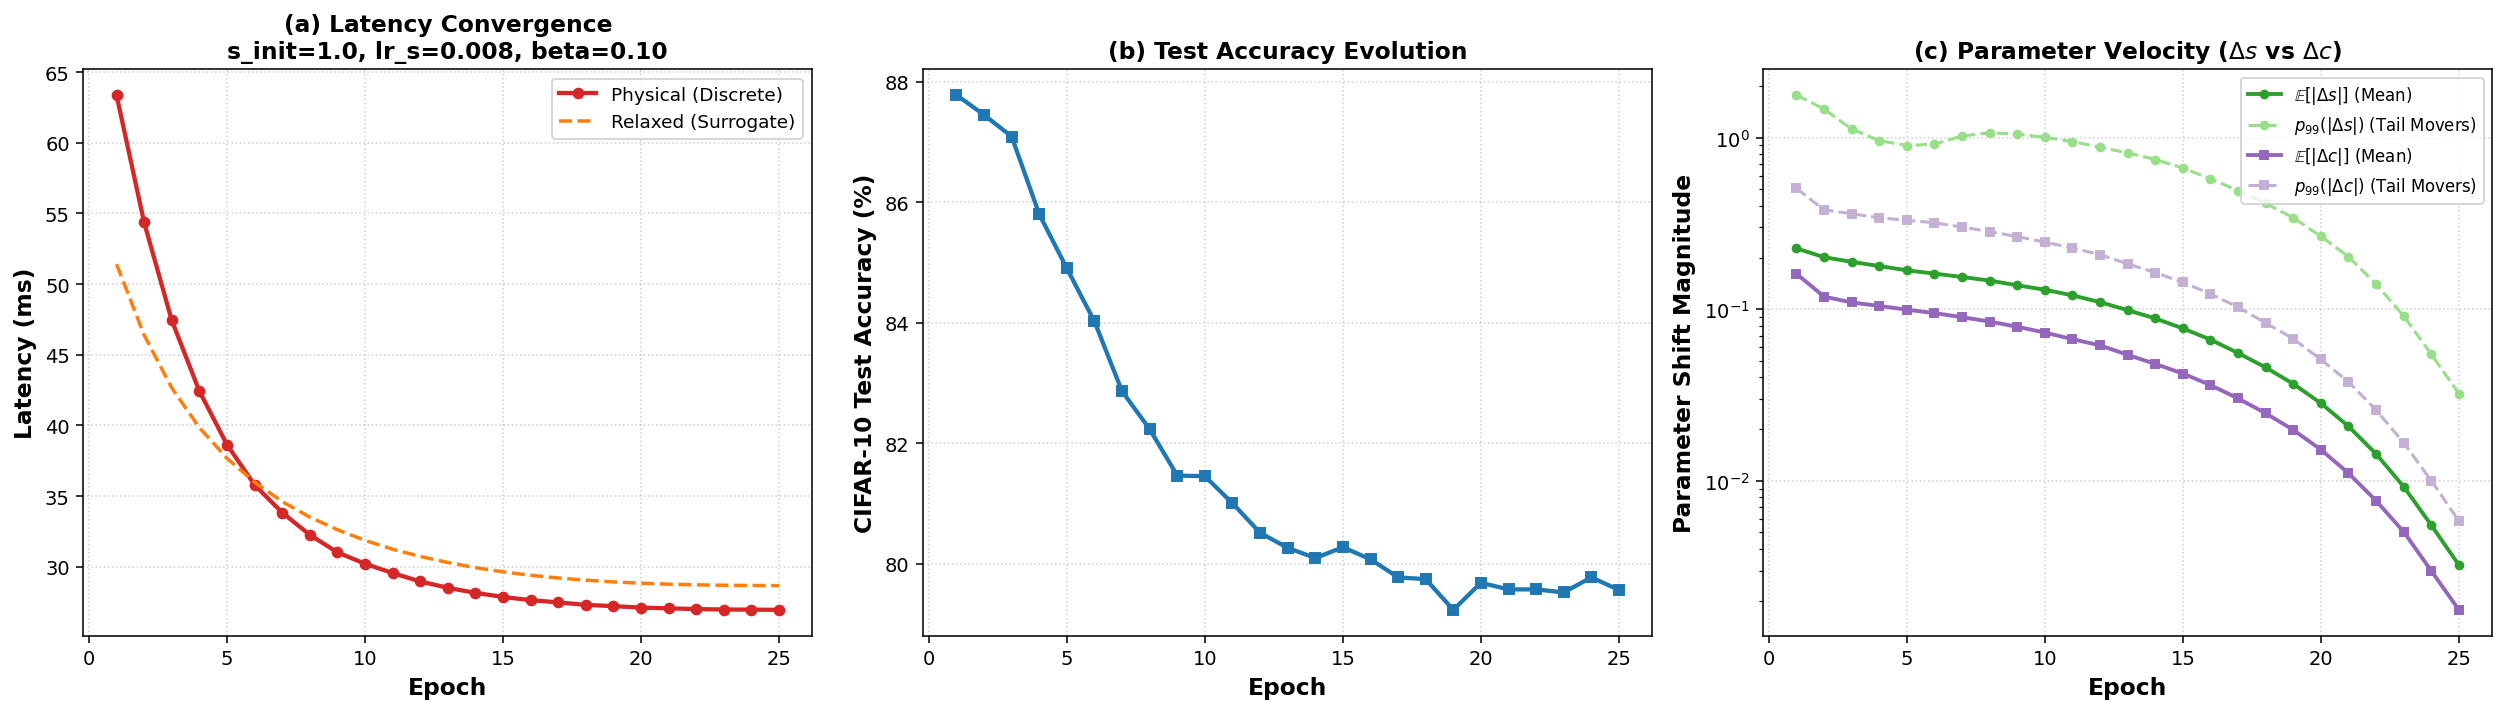

  >>> [RUN 01 SAVED TO DRIVE: run_01_diamond_sinit1.0_lrs0.008_b0.10_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [02/8] STARTING: run_02_diamond_sinit1.0_lrs0.008_b0.67_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_02_diamond_sinit1.0_lrs0.008_b0.67_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 67.22ms | Rel: 62.48ms | Acc: 87.74% | Δs: [μ=0.2581, p99=2.2092] | Δc: [μ=0.1586, p99=0.5091]
  [Ep 02/25] Phys: 60.14ms | Rel: 56.57ms | Acc: 87.80% | Δs: [μ=0.2599, p99=2.5355] | Δc: [μ=0.1102, p99=0.3564]
  [Ep 03/25] Phys: 54.63ms | Rel: 51.54ms | Acc: 87.62% | Δs: [μ=0.2620, p99=1.9891] | Δc: [μ=0.1036, p99=0.3367]
  [Ep 04/25] Phys: 50.33ms | Rel: 47.70ms | Acc: 87.42% | Δs: [μ=0.2593, p99=1.6683] | Δc: [μ=0.0979, p99=0.3252]
  [Ep 05/25] Phys: 46.95ms | Rel: 44.74ms | Acc: 86.89% | Δs: [μ=0.253

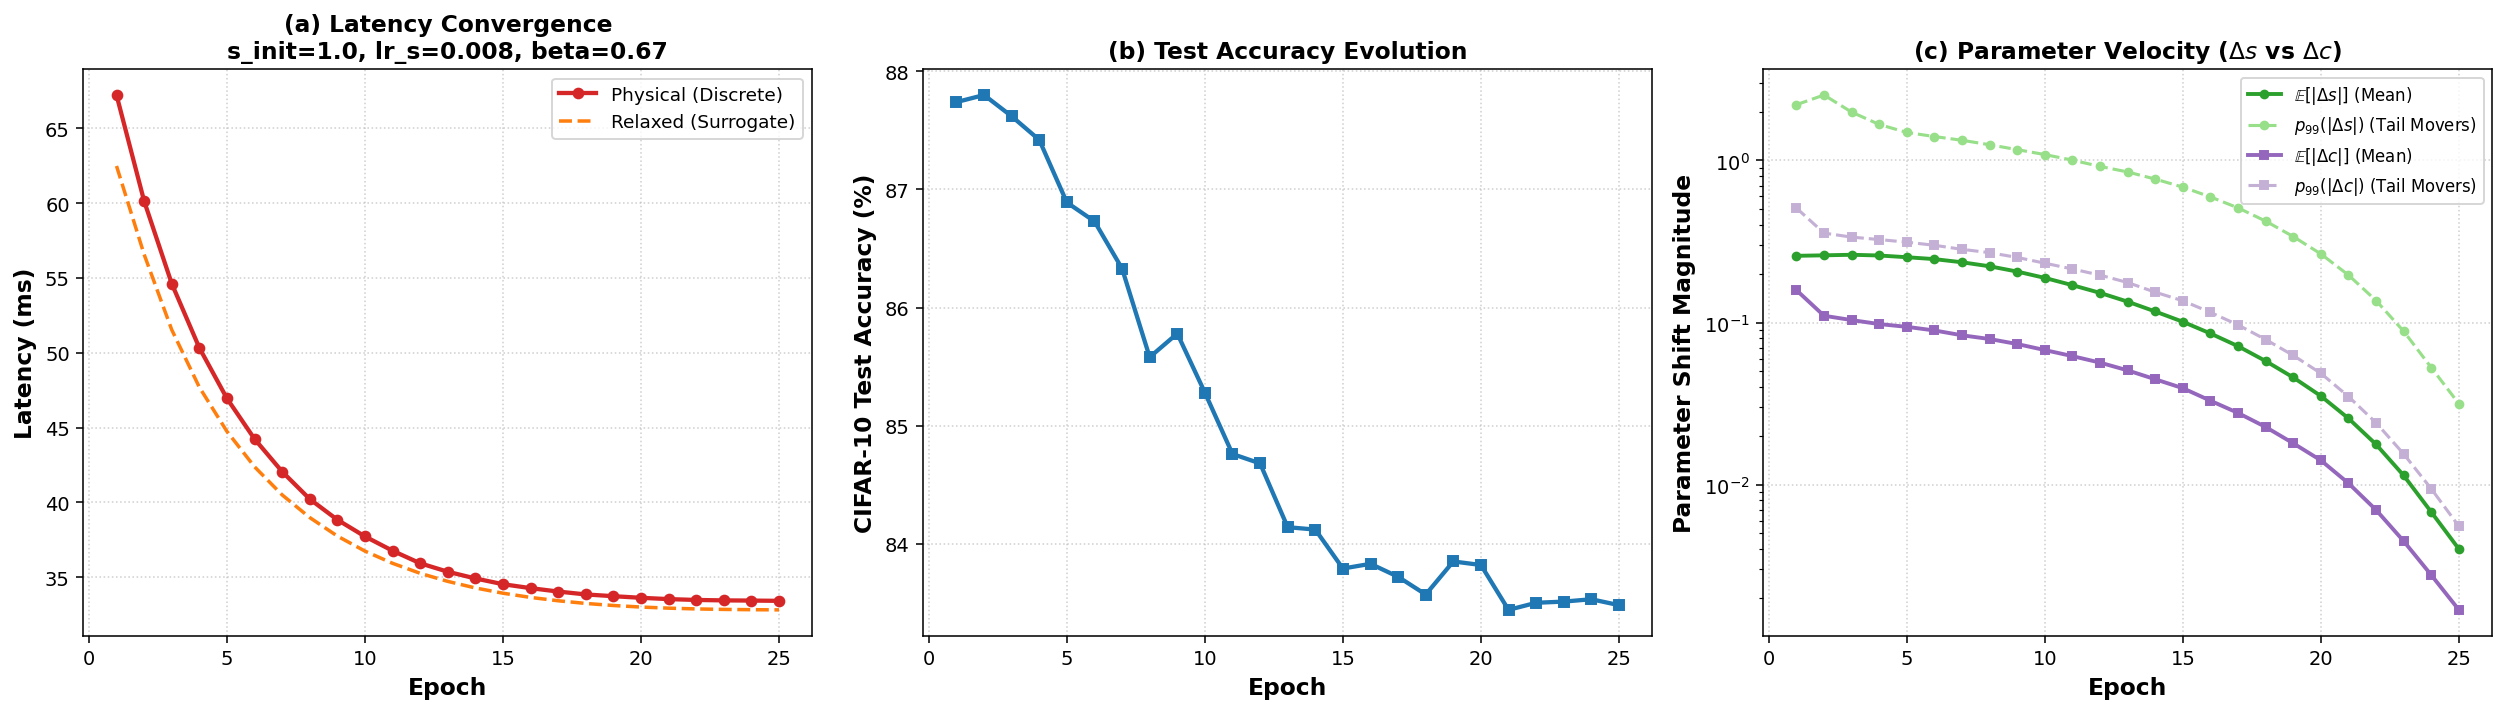

  >>> [RUN 02 SAVED TO DRIVE: run_02_diamond_sinit1.0_lrs0.008_b0.67_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [03/8] STARTING: run_03_diamond_sinit1.0_lrs0.030_b0.10_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_03_diamond_sinit1.0_lrs0.030_b0.10_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 41.50ms | Rel: 40.02ms | Acc: 84.60% | Δs: [μ=0.7766, p99=4.6746] | Δc: [μ=0.1465, p99=0.4676]
  [Ep 02/25] Phys: 32.68ms | Rel: 33.93ms | Acc: 83.06% | Δs: [μ=0.5978, p99=2.2211] | Δc: [μ=0.1120, p99=0.3652]
  [Ep 03/25] Phys: 29.13ms | Rel: 30.75ms | Acc: 81.34% | Δs: [μ=0.5586, p99=1.9175] | Δc: [μ=0.1025, p99=0.3434]
  [Ep 04/25] Phys: 27.35ms | Rel: 28.81ms | Acc: 81.54% | Δs: [μ=0.5323, p99=1.8482] | Δc: [μ=0.0963, p99=0.3265]
  [Ep 05/25] Phys: 26.31ms | Rel: 27.53ms | Acc: 81.85% | Δs: [μ=0.519

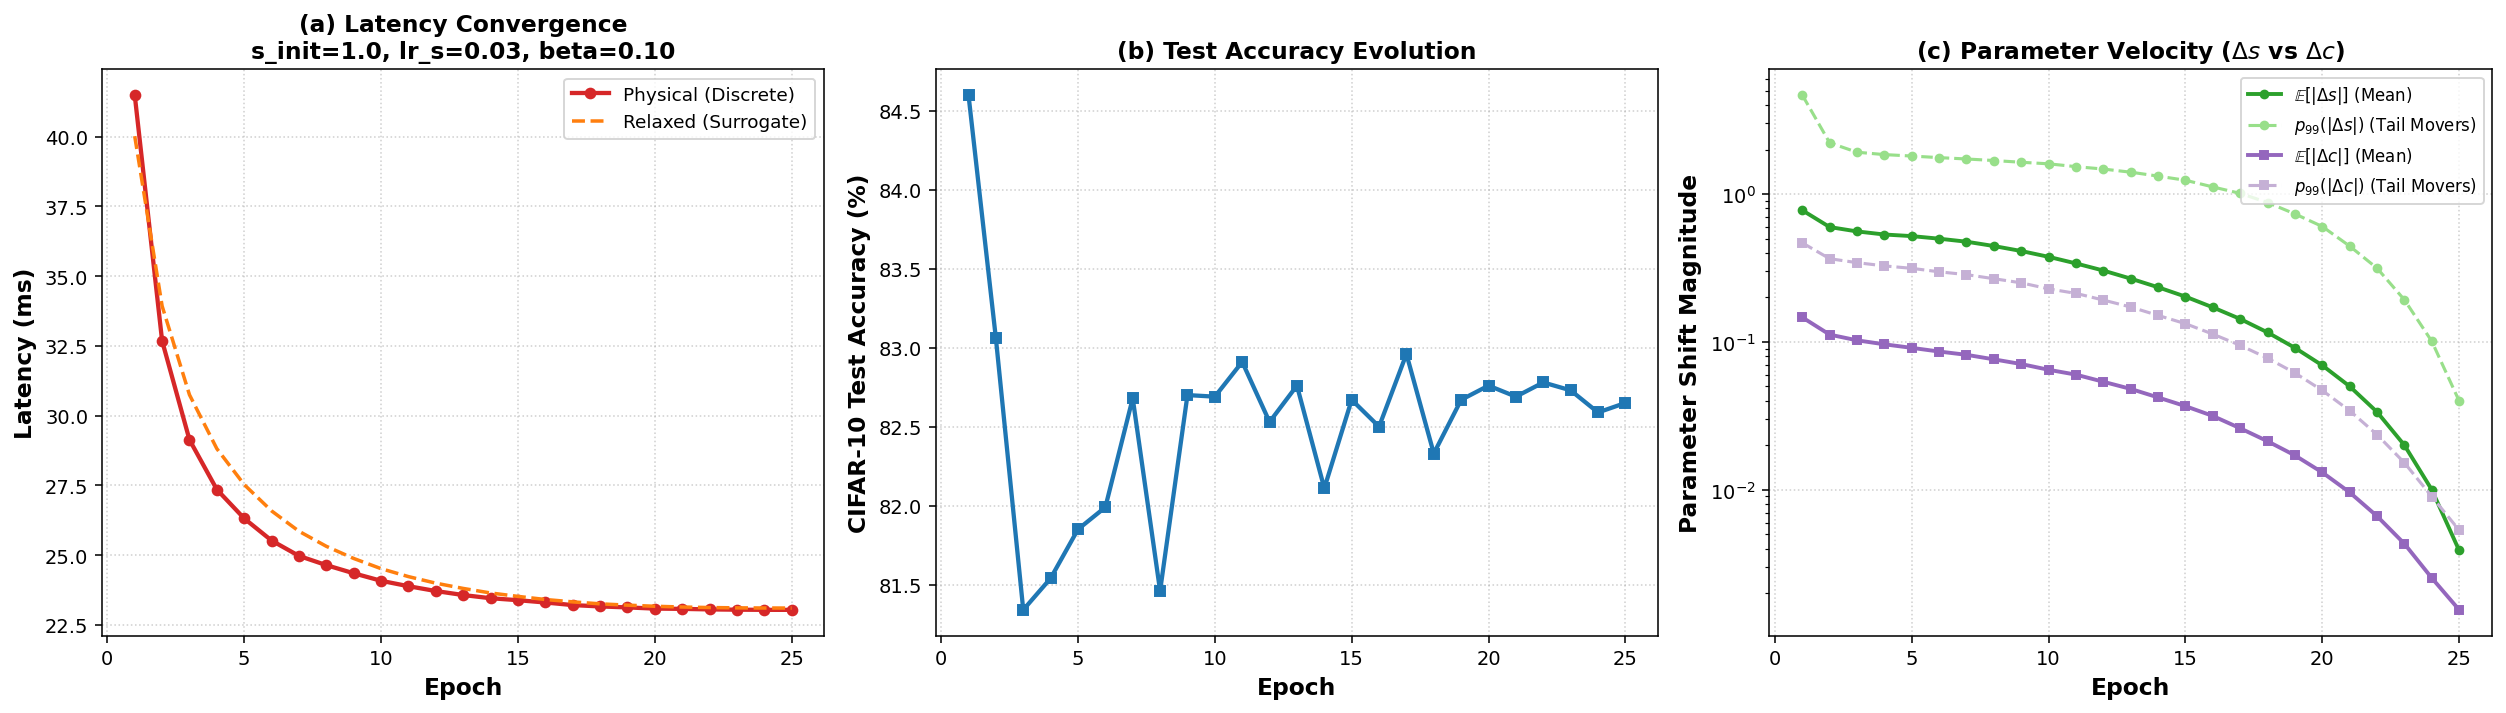

  >>> [RUN 03 SAVED TO DRIVE: run_03_diamond_sinit1.0_lrs0.030_b0.10_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [04/8] STARTING: run_04_diamond_sinit1.0_lrs0.030_b0.67_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_04_diamond_sinit1.0_lrs0.030_b0.67_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 52.26ms | Rel: 49.84ms | Acc: 87.50% | Δs: [μ=0.9488, p99=6.5808] | Δc: [μ=0.1303, p99=0.4170]
  [Ep 02/25] Phys: 41.33ms | Rel: 40.55ms | Acc: 86.60% | Δs: [μ=0.8501, p99=4.1840] | Δc: [μ=0.1045, p99=0.3435]
  [Ep 03/25] Phys: 36.21ms | Rel: 35.91ms | Acc: 85.45% | Δs: [μ=0.7694, p99=3.2959] | Δc: [μ=0.0966, p99=0.3264]
  [Ep 04/25] Phys: 33.71ms | Rel: 33.45ms | Acc: 84.06% | Δs: [μ=0.7005, p99=2.6759] | Δc: [μ=0.0907, p99=0.3137]
  [Ep 05/25] Phys: 32.26ms | Rel: 32.04ms | Acc: 83.97% | Δs: [μ=0.641

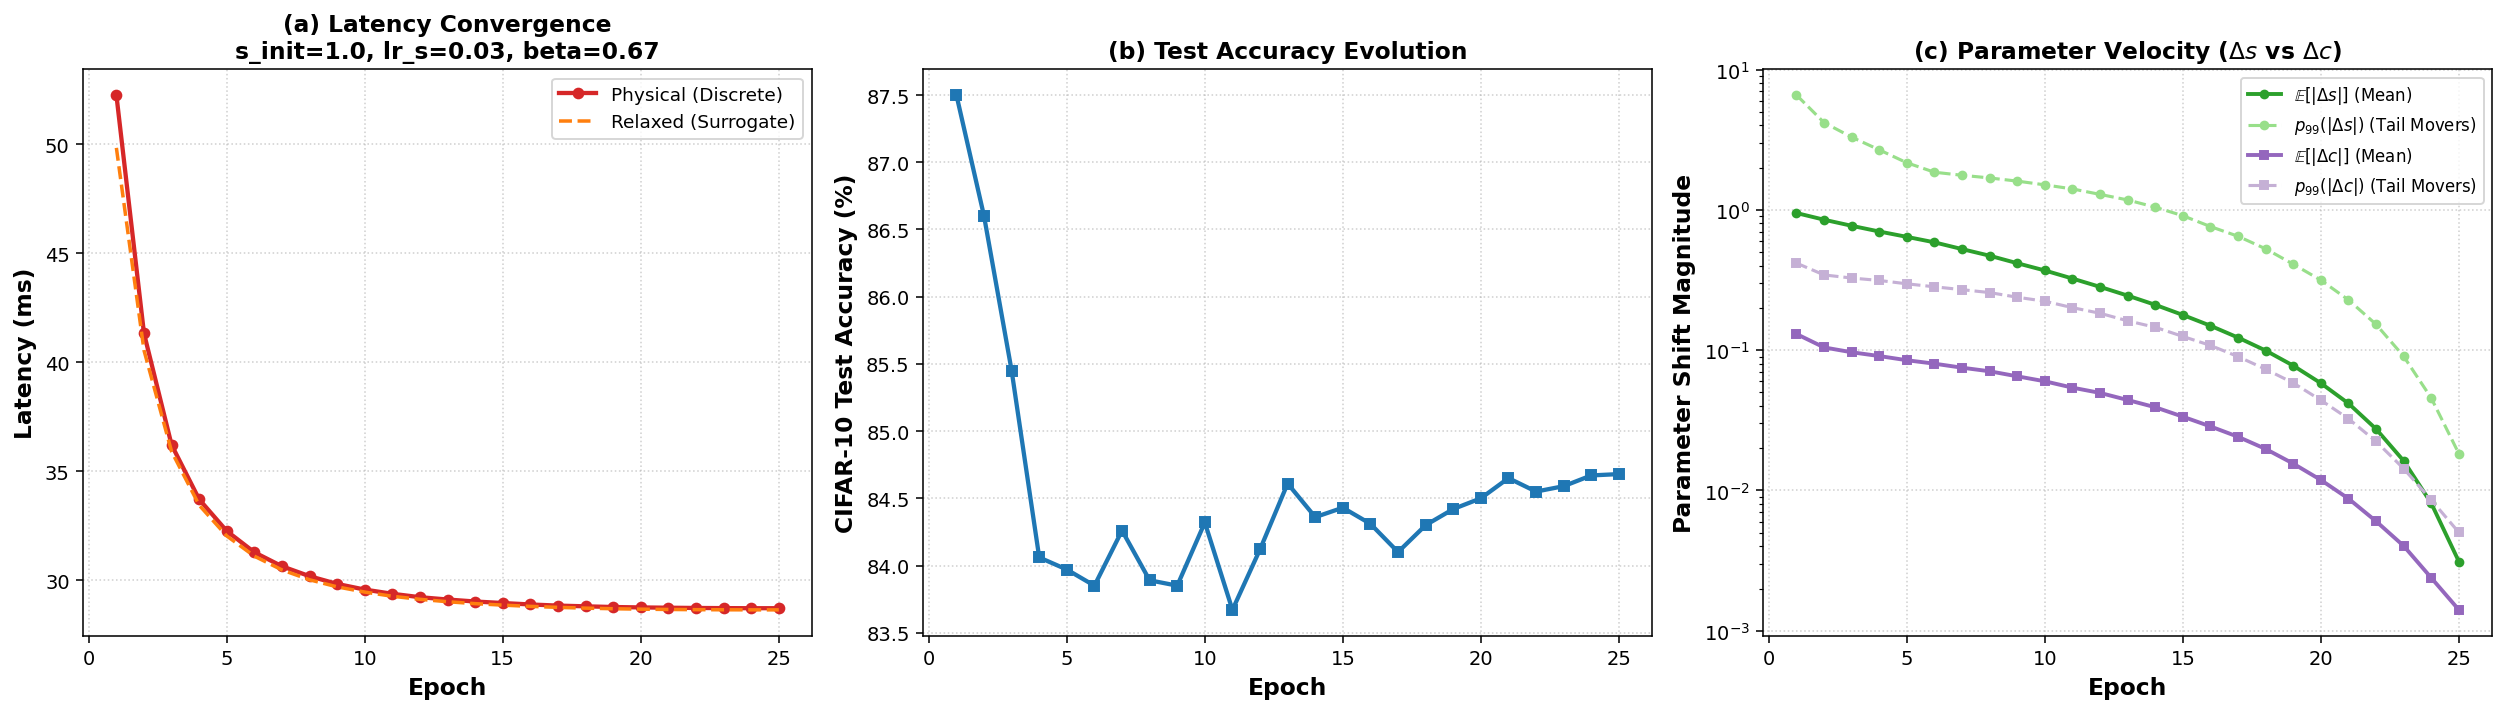

  >>> [RUN 04 SAVED TO DRIVE: run_04_diamond_sinit1.0_lrs0.030_b0.67_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [05/8] STARTING: run_05_diamond_sinit2.5_lrs0.008_b0.10_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_05_diamond_sinit2.5_lrs0.008_b0.10_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 68.09ms | Rel: 62.25ms | Acc: 87.72% | Δs: [μ=0.2766, p99=1.9684] | Δc: [μ=0.1396, p99=0.4308]
  [Ep 02/25] Phys: 63.54ms | Rel: 57.80ms | Acc: 87.88% | Δs: [μ=0.1994, p99=1.8865] | Δc: [μ=0.1198, p99=0.3777]
  [Ep 03/25] Phys: 58.10ms | Rel: 53.35ms | Acc: 87.95% | Δs: [μ=0.2002, p99=1.5091] | Δc: [μ=0.1141, p99=0.3635]
  [Ep 04/25] Phys: 53.94ms | Rel: 49.60ms | Acc: 88.04% | Δs: [μ=0.1924, p99=1.2425] | Δc: [μ=0.1104, p99=0.3528]
  [Ep 05/25] Phys: 50.20ms | Rel: 46.57ms | Acc: 87.82% | Δs: [μ=0.182

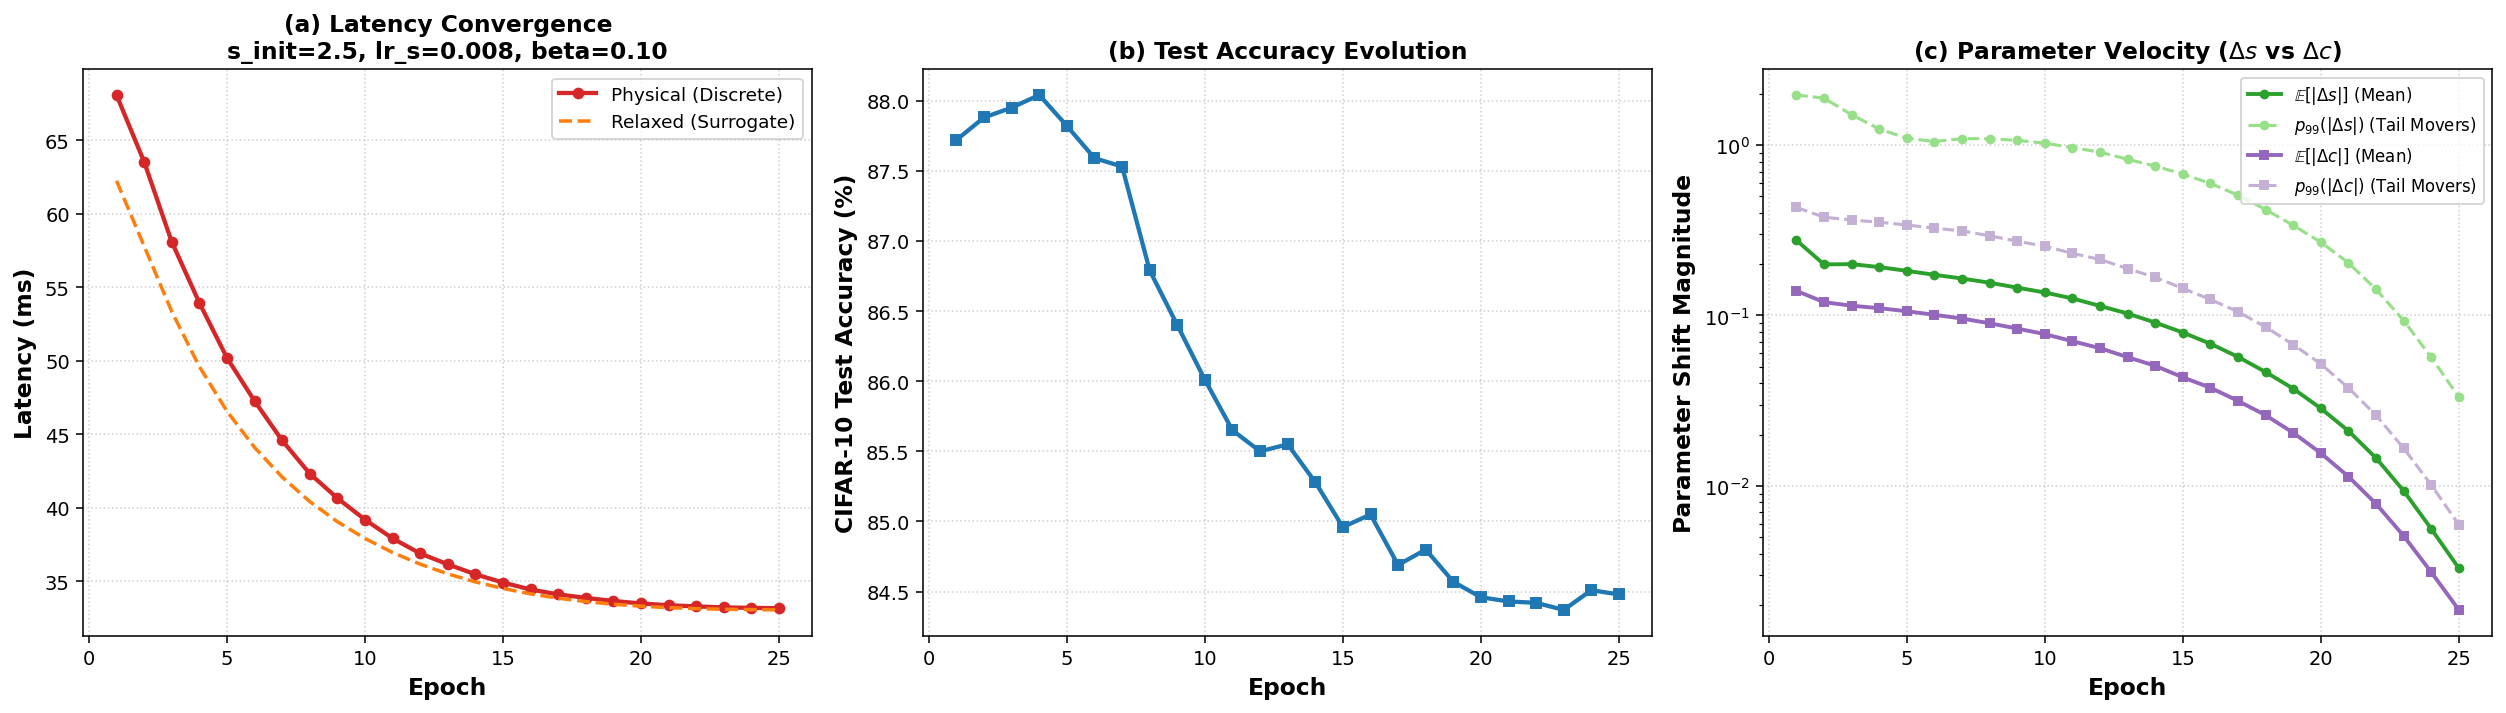

  >>> [RUN 05 SAVED TO DRIVE: run_05_diamond_sinit2.5_lrs0.008_b0.10_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [06/8] STARTING: run_06_diamond_sinit2.5_lrs0.008_b0.67_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_06_diamond_sinit2.5_lrs0.008_b0.67_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 68.93ms | Rel: 67.60ms | Acc: 87.68% | Δs: [μ=0.1822, p99=1.0337] | Δc: [μ=0.1436, p99=0.4525]
  [Ep 02/25] Phys: 67.22ms | Rel: 65.78ms | Acc: 87.79% | Δs: [μ=0.1854, p99=2.1418] | Δc: [μ=0.1176, p99=0.3765]
  [Ep 03/25] Phys: 64.22ms | Rel: 62.88ms | Acc: 87.79% | Δs: [μ=0.2008, p99=2.4792] | Δc: [μ=0.1117, p99=0.3584]
  [Ep 04/25] Phys: 61.07ms | Rel: 59.76ms | Acc: 87.76% | Δs: [μ=0.2084, p99=2.2387] | Δc: [μ=0.1076, p99=0.3447]
  [Ep 05/25] Phys: 58.21ms | Rel: 56.93ms | Acc: 87.81% | Δs: [μ=0.209

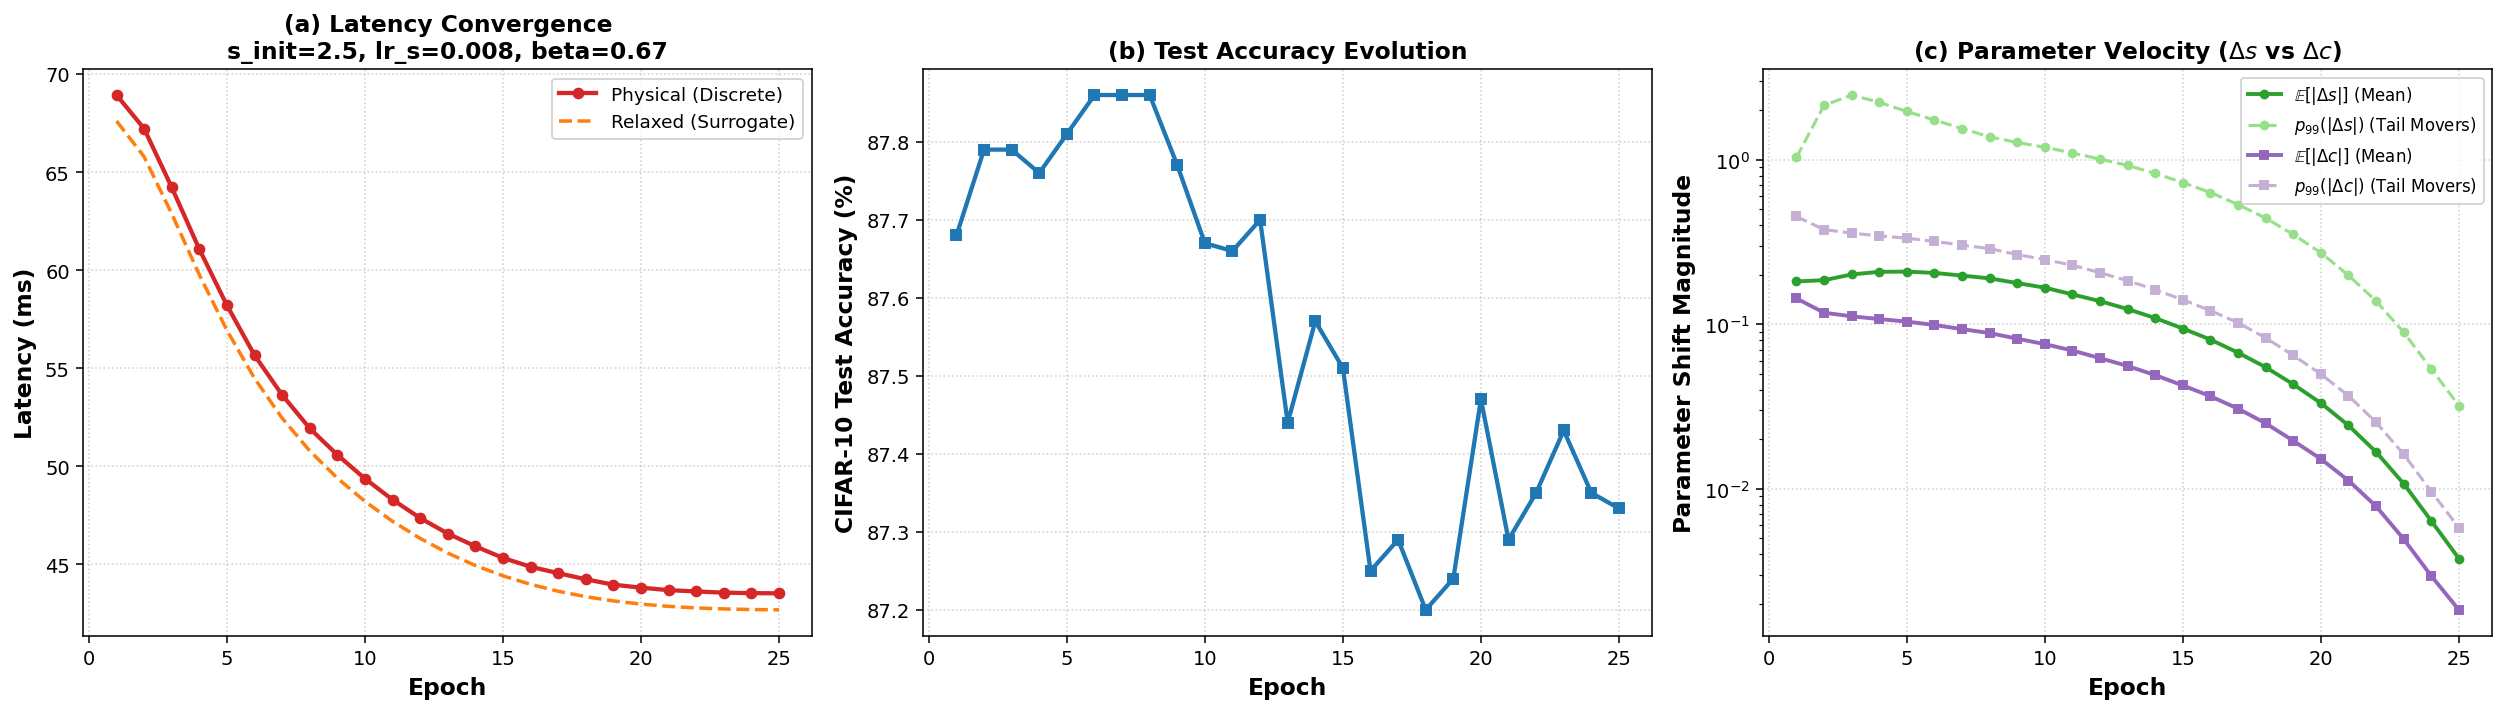

  >>> [RUN 06 SAVED TO DRIVE: run_06_diamond_sinit2.5_lrs0.008_b0.67_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [07/8] STARTING: run_07_diamond_sinit2.5_lrs0.030_b0.10_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_07_diamond_sinit2.5_lrs0.030_b0.10_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 49.43ms | Rel: 46.62ms | Acc: 87.71% | Δs: [μ=0.9787, p99=6.0169] | Δc: [μ=0.1336, p99=0.4341]
  [Ep 02/25] Phys: 38.46ms | Rel: 38.20ms | Acc: 86.66% | Δs: [μ=0.6438, p99=2.8017] | Δc: [μ=0.1199, p99=0.3922]
  [Ep 03/25] Phys: 33.62ms | Rel: 33.92ms | Acc: 85.21% | Δs: [μ=0.5813, p99=2.1524] | Δc: [μ=0.1092, p99=0.3594]
  [Ep 04/25] Phys: 30.93ms | Rel: 31.41ms | Acc: 84.23% | Δs: [μ=0.5421, p99=1.8949] | Δc: [μ=0.1018, p99=0.3384]
  [Ep 05/25] Phys: 29.14ms | Rel: 29.69ms | Acc: 83.67% | Δs: [μ=0.519

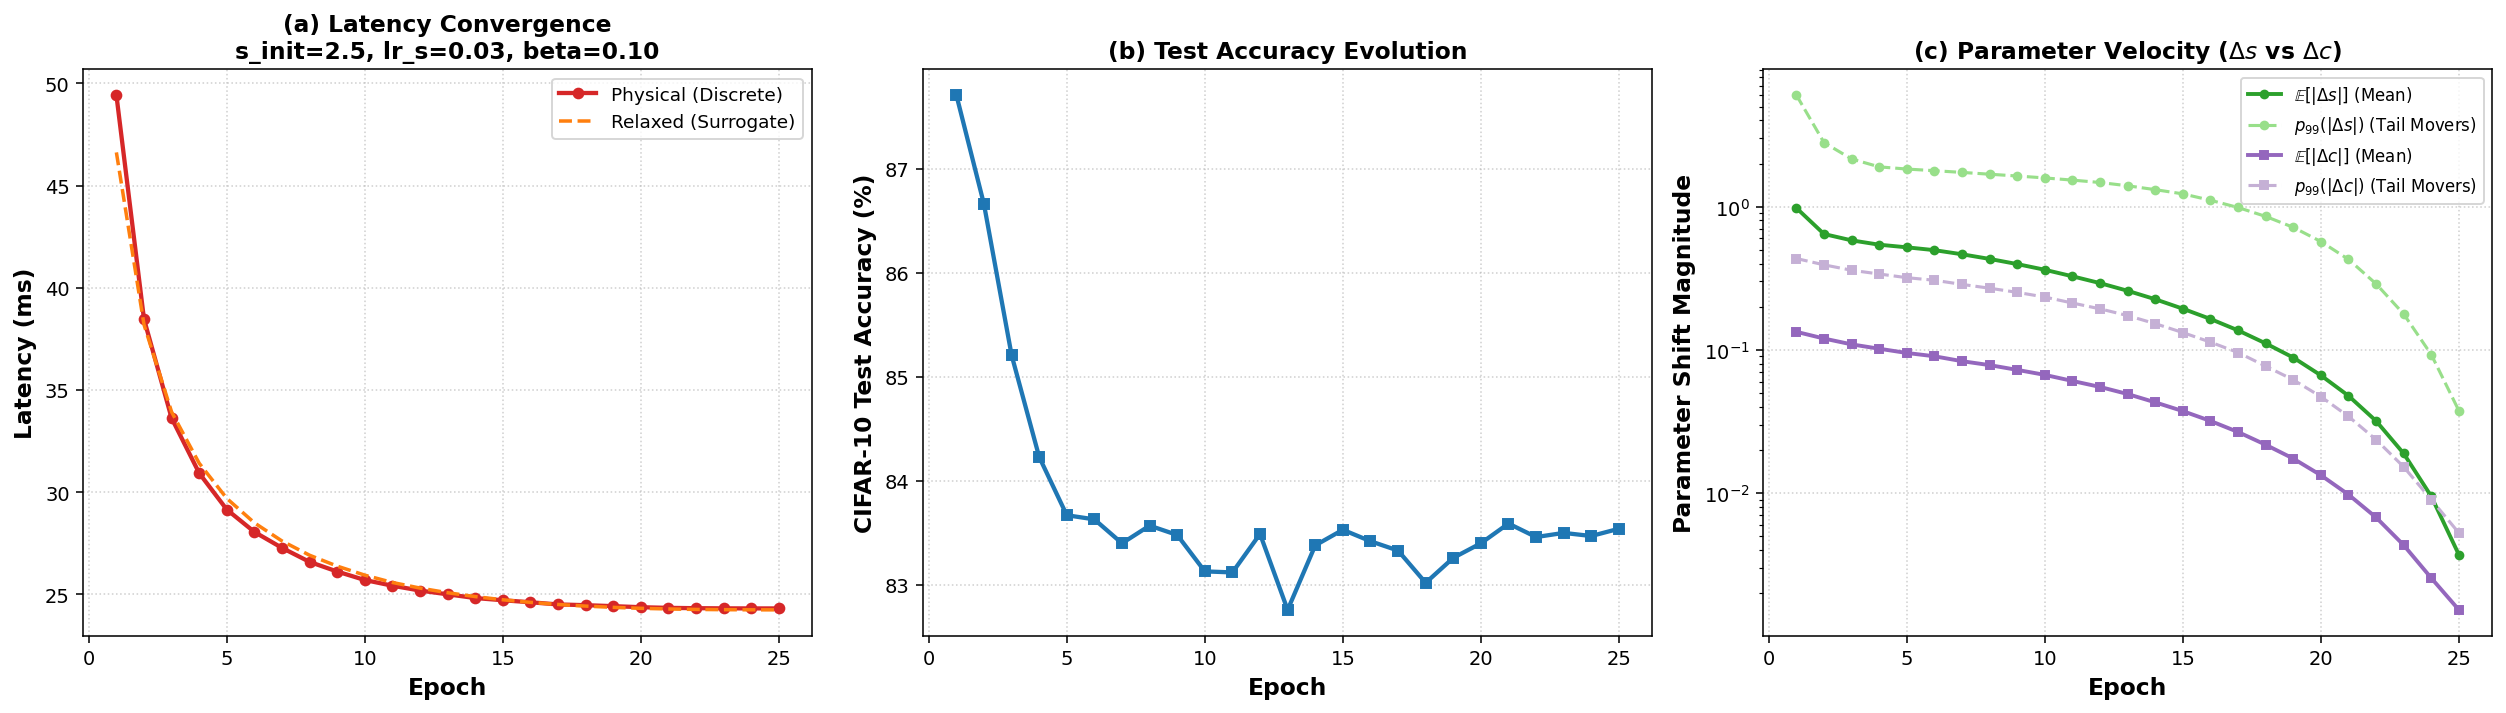

  >>> [RUN 07 SAVED TO DRIVE: run_07_diamond_sinit2.5_lrs0.030_b0.10_lam0.035_a10.0_lrc0.008_25ep]

------------------------------------------------------------------------
  [08/8] STARTING: run_08_diamond_sinit2.5_lrs0.030_b0.67_lam0.035_a10.0_lrc0.008_25ep
  Target Drive Directory: /content/drive/MyDrive/SemesterProject_Results/run_08_diamond_sinit2.5_lrs0.030_b0.67_lam0.035_a10.0_lrc0.008_25ep
------------------------------------------------------------------------
  [Ep 01/25] Phys: 61.13ms | Rel: 59.73ms | Acc: 87.99% | Δs: [μ=0.7527, p99=7.3673] | Δc: [μ=0.1269, p99=0.4052]
  [Ep 02/25] Phys: 51.06ms | Rel: 50.15ms | Acc: 87.99% | Δs: [μ=0.7727, p99=5.5729] | Δc: [μ=0.1125, p99=0.3632]
  [Ep 03/25] Phys: 45.27ms | Rel: 44.70ms | Acc: 87.42% | Δs: [μ=0.7248, p99=4.3427] | Δc: [μ=0.1058, p99=0.3464]
  [Ep 04/25] Phys: 41.89ms | Rel: 41.42ms | Acc: 87.00% | Δs: [μ=0.6743, p99=3.4918] | Δc: [μ=0.0988, p99=0.3296]
  [Ep 05/25] Phys: 39.61ms | Rel: 39.21ms | Acc: 86.85% | Δs: [μ=0.631

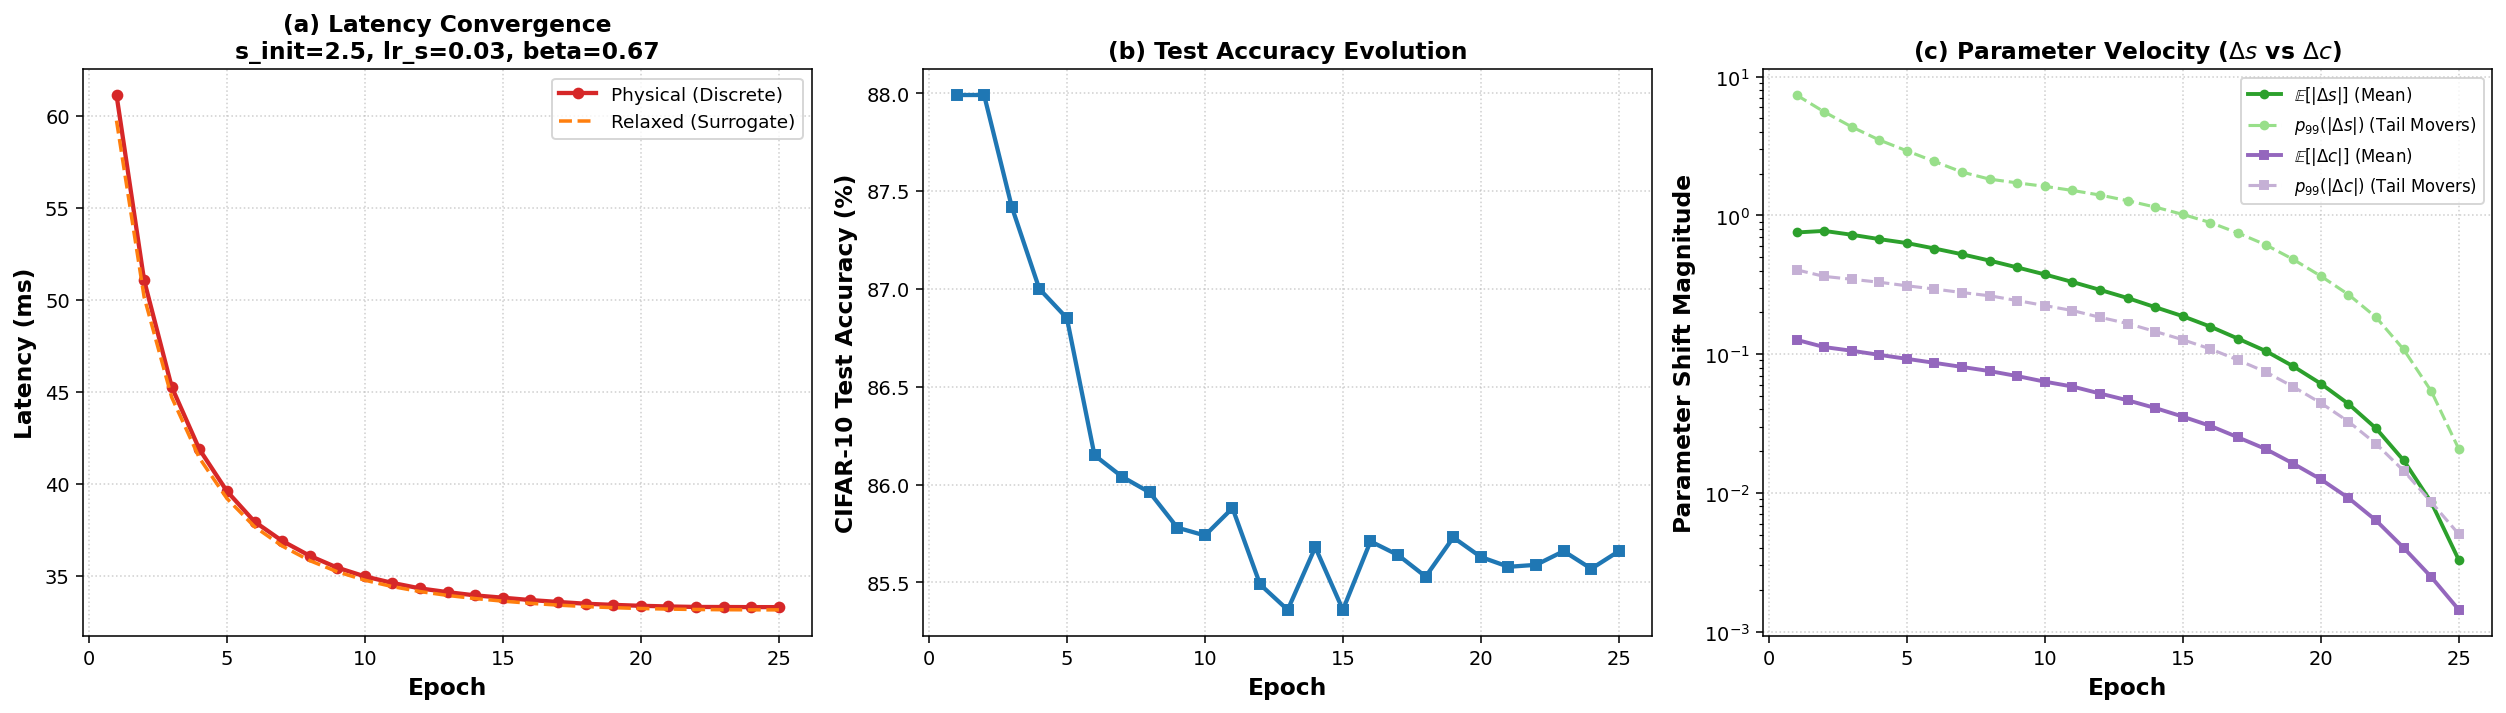

  >>> [RUN 08 SAVED TO DRIVE: run_08_diamond_sinit2.5_lrs0.030_b0.67_lam0.035_a10.0_lrc0.008_25ep]

>>> ALL SWEEP RUNS COMPLETED AND FULLY SYNCED!


In [ ]:
# ==============================================================================
# Cell 7: Fast Asynchronous Sweep with Vectorized GPU Caching & Stable Kinematics
# ==============================================================================
import copy
import itertools
import json
import math
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

assert torch.cuda.is_available(), "CRITICAL: Colab GPU disconnected! Go to Runtime -> Change runtime type -> T4 GPU."
device = torch.device("cuda")

# ------------------------------------------------------------------------------
# 0. Hardware & Storage Directories
# ------------------------------------------------------------------------------
OUTPUT_DIR = "/content/results"
DRIVE_BACKUP_DIR = "/content/drive/MyDrive/SemesterProject_Results"
LOCAL_CACHE_DIR = "/content/hf_backbones_cache"
os.makedirs(OUTPUT_DIR, exist_ok=True)

drive_mounted = False
try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        drive_mounted = True
except Exception:
    pass

# ------------------------------------------------------------------------------
# 1. Sweep Configuration & Topology Setup
# ------------------------------------------------------------------------------
TOPO_KEY = "diamond"
CONFIG_KEY = "diamond_case4_dual_skew"
topo_cfg = CONFIG_REGISTRY[CONFIG_KEY]

EPOCHS = 25
BATCH_SIZE = 128
ALPHA_FIXED = 10.0
LR_C_FIXED = 0.008

S_INIT_GRID = [1.0, 2.5]
LR_S_GRID = [0.008, 0.03]
BETA_GRID = [0.10, 2.0 / 3.0]
LAMBDA_GRID = [0.035]
grid_combinations = list(itertools.product(S_INIT_GRID, LR_S_GRID, BETA_GRID, LAMBDA_GRID))

weight_path = os.path.join(LOCAL_CACHE_DIR, f"backbone_{TOPO_KEY}.pt")
assert os.path.exists(weight_path), f"Backbone weights missing at {weight_path}. Run Cell 6 first!"

# ------------------------------------------------------------------------------
# 2. Fast DAG Engine (Pre-allocates constant delay tensors on GPU)
# ------------------------------------------------------------------------------
class FastDAGTimingEngine(DAGTimingEngine):
    def __init__(self, nodes, edges):
        super().__init__(nodes, edges)
        self.t_exec_tensors = {
            j: torch.tensor(nodes[j].exec_time_ms, device=device, dtype=torch.float32)
            for j in self.nodes
        }
        self.t_prop_tensors = {
            e: torch.tensor(edges[e].prop_delay_ms, device=device, dtype=torch.float32)
            for e in self.edges
        }

    def compute_relaxed_latency(self, bottlenecks, beta: float, alpha: float) -> torch.Tensor:
        t_tilde = {}
        for j in self.topo_order:
            t_exec = self.t_exec_tensors[j]
            if len(self.parents[j]) == 0:
                t_tilde[j] = t_exec
            else:
                branch_arrivals = []
                for i in self.parents[j]:
                    t_trans = bottlenecks[(i, j)].expected_transmission_time_ms(beta)
                    t_prop = self.t_prop_tensors[(i, j)]
                    branch_arrivals.append(t_tilde[i] + t_prop + t_trans)
                stacked = torch.stack(branch_arrivals)
                z_max = torch.max(stacked).detach()
                lse = z_max + (1.0 / alpha) * torch.log(torch.sum(torch.exp(alpha * (stacked - z_max))))
                t_tilde[j] = t_exec + lse
        return t_tilde[self.terminal_node]

timing_engine = FastDAGTimingEngine(topo_cfg["nodes"], topo_cfg["edges"])

# ------------------------------------------------------------------------------
# 3. Direct Vectorized Caching into GPU VRAM (No DataLoader Workers, 0.3s Total)
# ------------------------------------------------------------------------------
print(">>> Vectorizing and caching CIFAR-10 directly into GPU VRAM (~600 MB)...")

cifar_mean = torch.tensor([0.4914, 0.4822, 0.4465], device=device).view(1, 3, 1, 1)
cifar_std = torch.tensor([0.2470, 0.2435, 0.2616], device=device).view(1, 3, 1, 1)

# Direct numpy -> GPU tensor conversion (matches transforms.ToTensor + Normalize)
def vectorize_dataset(dataset):
    # data: (N, 32, 32, 3) uint8 -> permute to (N, 3, 32, 32)
    x = torch.from_numpy(dataset.data).permute(0, 3, 1, 2).to(device, non_blocking=True).float() / 255.0
    x = (x - cifar_mean) / cifar_std
    y = torch.tensor(dataset.targets, dtype=torch.long, device=device)
    return x, y

X_train_gpu, Y_train_gpu = vectorize_dataset(trainset)
X_test_gpu, Y_test_gpu = vectorize_dataset(testset)
N_SAMPLES = X_train_gpu.size(0)

print(f">>> VRAM Cache ready: {N_SAMPLES} train, {X_test_gpu.size(0)} test samples loaded directly on {device}.")

# ------------------------------------------------------------------------------
# 4. Zero-Sync Bottleneck Forward Patch
# ------------------------------------------------------------------------------
def _fast_edge_bottleneck_forward(self, z: torch.Tensor, beta: float, deterministic: bool = False):
    s_broad = self.s.unsqueeze(0)
    c_broad = self.c.unsqueeze(0)
    if not deterministic:
        eps = torch.rand_like(s_broad).clamp(1e-6, 1.0 - 1e-6)
        logits_eps = torch.log(eps) - torch.log(1.0 - eps)
        m_tilde = torch.sigmoid((logits_eps + s_broad) / beta)
        m_bar = m_tilde * (self.gate_cfg.zeta - self.gate_cfg.gamma) + self.gate_cfg.gamma
        m = torch.clamp(m_bar, 0.0, 1.0)
        return z * m + (1.0 - m) * c_broad, None
    else:
        threshold = beta * math.log(-self.gate_cfg.gamma / self.gate_cfg.zeta)
        hard_mask = (s_broad >= threshold).float()
        return z * hard_mask + (1.0 - hard_mask) * c_broad, None

EdgeBottleneck.forward = _fast_edge_bottleneck_forward

# ------------------------------------------------------------------------------
# 5. Master Sweep Execution Loop
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print(f">>> HIGH-SPEED KINEMATICS SWEEP ({len(grid_combinations)} RUNS)")
print(f">>> GPU: {torch.cuda.get_device_name(0)} | Asynchronous Pipeline Active")
print(f">>> Topology: {TOPO_KEY} | Fixed Alpha: {ALPHA_FIXED} | Fixed lr_c: {LR_C_FIXED} | Epochs: {EPOCHS}")
print("=" * 80 + "\n")

for run_idx, (s_init, lr_s, beta_val, lam_val) in enumerate(grid_combinations, 1):
    folder_name = (
        f"run_{run_idx:02d}_{TOPO_KEY}_sinit{s_init:.1f}_lrs{lr_s:.3f}_"
        f"b{beta_val:.2f}_lam{lam_val:.3f}_a{ALPHA_FIXED:.1f}_lrc{LR_C_FIXED}_{EPOCHS}ep"
    )
    run_local_dir = os.path.join(OUTPUT_DIR, folder_name)
    run_drive_dir = os.path.join(DRIVE_BACKUP_DIR, folder_name) if drive_mounted else None

    os.makedirs(run_local_dir, exist_ok=True)
    if run_drive_dir:
        os.makedirs(run_drive_dir, exist_ok=True)

    print(f"------------------------------------------------------------------------")
    print(f"  [{run_idx:02d}/{len(grid_combinations)}] STARTING: {folder_name}")
    print(f"  Target Drive Directory: {run_drive_dir}")
    print(f"------------------------------------------------------------------------")

    meta_payload = {
        "run_index": run_idx,
        "folder_name": folder_name,
        "topology": TOPO_KEY,
        "s_init": s_init,
        "lr_s": lr_s,
        "beta": beta_val,
        "lambda": lam_val,
        "alpha": ALPHA_FIXED,
        "lr_c": LR_C_FIXED,
        "epochs": EPOCHS,
        "device": torch.cuda.get_device_name(0),
    }
    with open(os.path.join(run_local_dir, "metadata.json"), "w") as f:
        json.dump(meta_payload, f, indent=4)
    if run_drive_dir:
        shutil.copy(os.path.join(run_local_dir, "metadata.json"), os.path.join(run_drive_dir, "metadata.json"))

    # Model Setup
    gate_cfg = GateConfig(s_init=s_init, alpha=ALPHA_FIXED, beta_init=beta_val, beta_min=beta_val)
    model = DynamicSplitDAG(TOPO_KEY, gate_cfg, topo_cfg["edges"]).to(device)

    weights = torch.load(weight_path, map_location=device, weights_only=False)
    filtered = {k: v for k, v in weights.items() if not (k.endswith(".s") or k.endswith(".c"))}
    model.load_state_dict(filtered, strict=False)

    # Freeze Backbone (BatchNorm in eval mode)
    model.eval()
    for name, p in model.named_parameters():
        if name.endswith(".s") or name.endswith(".c"):
            p.requires_grad = True
            if name.endswith(".s"): p.data.fill_(s_init)
            if name.endswith(".c"): p.data.zero_()
        else:
            p.requires_grad = False

    bneck_map = model.get_bottleneck_map()
    opt = optim.Adam([
        {"params": [b.s for b in bneck_map.values()], "lr": lr_s, "weight_decay": 0.0},
        {"params": [b.c for b in bneck_map.values()], "lr": LR_C_FIXED, "weight_decay": 0.0},
    ], betas=(0.9, 0.99), eps=1e-8)

    # Cosine scheduler to decay parameter velocity smoothly toward zero
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-4)
    scaler = torch.amp.GradScaler('cuda')
    crit = nn.CrossEntropyLoss()

    prev_s = {k: b.s.detach().clone() for k, b in bneck_map.items()}
    prev_c = {k: b.c.detach().clone() for k, b in bneck_map.items()}

    hist_records = []

    # High-Speed Epoch Loop (~1.5 to 2.0s per epoch)
    for ep in range(EPOCHS):
        perm = torch.randperm(N_SAMPLES, device=device)

        for i in range(0, N_SAMPLES, BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            x, y = X_train_gpu[idx], Y_train_gpu[idx]

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                y_hat = model(x, beta=beta_val, deterministic=False)
                task_loss = crit(y_hat, y)
                tilde_t = timing_engine.compute_relaxed_latency(bneck_map, beta=beta_val, alpha=ALPHA_FIXED)
                loss = task_loss + lam_val * tilde_t

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        scheduler.step()

        # Parameter Kinematics
        with torch.no_grad():
            ds_list = [(b.s - prev_s[k]).abs().flatten() for k, b in bneck_map.items()]
            dc_list = [(b.c - prev_c[k]).abs().flatten() for k, b in bneck_map.items()]
            all_ds = torch.cat(ds_list)
            all_dc = torch.cat(dc_list)

            mean_ds = all_ds.mean().item()
            tail_ds = torch.quantile(all_ds, 0.99).item()
            max_ds = all_ds.max().item()

            mean_dc = all_dc.mean().item()
            tail_dc = torch.quantile(all_dc, 0.99).item()
            max_dc = all_dc.max().item()

            for k, b in bneck_map.items():
                prev_s[k].copy_(b.s)
                prev_c[k].copy_(b.c)

        # Deterministic Evaluation on Test Set (<0.08s on GPU)
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                test_preds = model(X_test_gpu, beta=beta_val, deterministic=True)
            acc = (test_preds.argmax(dim=1) == Y_test_gpu).float().mean().item() * 100.0
            lat_phys = timing_engine.compute_physical_latency(bneck_map, beta=beta_val, deterministic=True)
            lat_relaxed = float(timing_engine.compute_relaxed_latency(bneck_map, beta=beta_val, alpha=ALPHA_FIXED).item())

        print(
            f"  [Ep {ep+1:02d}/{EPOCHS}] Phys: {lat_phys:5.2f}ms | Rel: {lat_relaxed:5.2f}ms | Acc: {acc:5.2f}% | "
            f"Δs: [μ={mean_ds:.4f}, p99={tail_ds:.4f}] | "
            f"Δc: [μ={mean_dc:.4f}, p99={tail_dc:.4f}]"
        )

        hist_records.append({
            "epoch": ep + 1,
            "accuracy_pct": acc,
            "latency_physical_ms": lat_phys,
            "latency_relaxed_ms": lat_relaxed,
            "estimator_gap_ms": abs(lat_relaxed - lat_phys),
            "mean_delta_s": mean_ds,
            "p99_delta_s": tail_ds,
            "max_delta_s": max_ds,
            "mean_delta_c": mean_dc,
            "p99_delta_c": tail_dc,
            "max_delta_c": max_dc,
        })

    # --------------------------------------------------------------------------
    # 6. Save Data & Generate Figures ONCE Per Run (~0.3s execution time)
    # --------------------------------------------------------------------------
    df_records = pd.DataFrame(hist_records)
    csv_local = os.path.join(run_local_dir, "trajectory.csv")
    df_records.to_csv(csv_local, index=False)
    if run_drive_dir:
        shutil.copy(csv_local, os.path.join(run_drive_dir, "trajectory.csv"))

    ep_axis = [r["epoch"] for r in hist_records]
    acc_axis = [r["accuracy_pct"] for r in hist_records]
    lat_axis = [r["latency_physical_ms"] for r in hist_records]
    rel_axis = [r["latency_relaxed_ms"] for r in hist_records]
    ds_mean = [r["mean_delta_s"] for r in hist_records]
    ds_p99 = [r["p99_delta_s"] for r in hist_records]
    dc_mean = [r["mean_delta_c"] for r in hist_records]
    dc_p99 = [r["p99_delta_c"] for r in hist_records]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), dpi=140)

    # Panel (a): Latency Trajectory
    axes[0].plot(ep_axis, lat_axis, "o-", color="#D62728", linewidth=2.2, markersize=5, label="Physical (Discrete)")
    axes[0].plot(ep_axis, rel_axis, "--", color="#FF7F0E", linewidth=1.8, label="Relaxed (Surrogate)")
    axes[0].set_xlabel("Epoch", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Latency (ms)", fontsize=12, fontweight="bold")
    axes[0].set_title(f"(a) Latency Convergence\ns_init={s_init}, lr_s={lr_s}, beta={beta_val:.2f}", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].legend(loc="upper right", fontsize=9.5)

    # Panel (b): Test Accuracy
    axes[1].plot(ep_axis, acc_axis, "s-", color="#1F77B4", linewidth=2.2, markersize=5)
    axes[1].set_xlabel("Epoch", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("CIFAR-10 Test Accuracy (%)", fontsize=12, fontweight="bold")
    axes[1].set_title("(b) Test Accuracy Evolution", fontsize=12, fontweight="bold")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    # Panel (c): Parameter Velocity Kinematics (Log Scale)
    axes[2].plot(ep_axis, ds_mean, "o-", color="#2CA02C", linewidth=2.0, markersize=4, label=r"$\mathbb{E}[|\Delta s|]$ (Mean)")
    axes[2].plot(ep_axis, ds_p99, "o--", color="#98DF8A", linewidth=1.6, markersize=4, label=r"$p_{99}(|\Delta s|)$ (Tail Movers)")
    axes[2].plot(ep_axis, dc_mean, "s-", color="#9467BD", linewidth=2.0, markersize=4, label=r"$\mathbb{E}[|\Delta c|]$ (Mean)")
    axes[2].plot(ep_axis, dc_p99, "s--", color="#C5B0D5", linewidth=1.6, markersize=4, label=r"$p_{99}(|\Delta c|)$ (Tail Movers)")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch", fontsize=12, fontweight="bold")
    axes[2].set_ylabel("Parameter Shift Magnitude", fontsize=12, fontweight="bold")
    axes[2].set_title(r"(c) Parameter Velocity ($\Delta s$ vs $\Delta c$)", fontsize=12, fontweight="bold")
    axes[2].grid(True, linestyle=":", alpha=0.6)
    axes[2].legend(loc="upper right", fontsize=8.5)

    plt.tight_layout()

    pdf_out = os.path.join(run_local_dir, "trajectory_kinematics.pdf")
    png_out = os.path.join(run_local_dir, "trajectory_kinematics.png")
    plt.savefig(pdf_out, format="pdf", bbox_inches="tight")
    plt.savefig(png_out, format="png", dpi=250, bbox_inches="tight")

    if run_drive_dir:
        shutil.copy(pdf_out, os.path.join(run_drive_dir, "trajectory_kinematics.pdf"))
        shutil.copy(png_out, os.path.join(run_drive_dir, "trajectory_kinematics.png"))

    plt.show()
    plt.close(fig)

    print(f"  >>> [RUN {run_idx:02d} SAVED TO DRIVE: {folder_name}]\n")

print("=" * 80)
print(">>> ALL SWEEP RUNS COMPLETED AND FULLY SYNCED!")
print("=" * 80)

In [8]:
# ==============================================================================
# Cell 8: Complete 4-Case Diamond Topology ALM Benchmark & Hierarchical Suite
# ==============================================================================
import copy
import itertools
import json
import math
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

assert torch.cuda.is_available(), "CRITICAL: GPU disconnected! Ensure GPU runtime is active."
device = torch.device("cuda")

# ------------------------------------------------------------------------------
# 0. Root Directories & Drive Setup
# ------------------------------------------------------------------------------
ROOT_OUTPUT_DIR = "/content/results/diamond_alm_benchmark"
ROOT_DRIVE_DIR = "/content/drive/MyDrive/SemesterProject_Results/diamond_alm_benchmark"
LOCAL_CACHE_DIR = "/content/hf_backbones_cache"
os.makedirs(ROOT_OUTPUT_DIR, exist_ok=True)

drive_mounted = False
try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    if os.path.exists("/content/drive/MyDrive"):
        os.makedirs(ROOT_DRIVE_DIR, exist_ok=True)
        drive_mounted = True
except Exception:
    pass

TOPO_KEY = "diamond"
weight_path = os.path.join(LOCAL_CACHE_DIR, f"backbone_{TOPO_KEY}.pt")
assert os.path.exists(weight_path), f"Backbone weights missing at {weight_path}. Run Cell 6 first!"

# ------------------------------------------------------------------------------
# 1. Hardware Profiles: The 4 Diamond Skew Cases
# ------------------------------------------------------------------------------
DIAMOND_CASES = {
    "case_1_uniform": {
        "title": "Case 1: Fully Uniform",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A", exec_time_ms=3.0),
            2: NodeConfig("Worker_B", exec_time_ms=3.0),
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(30.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(30.0, 1.0),
        },
    },
    "case_2_capacity_skew": {
        "title": "Case 2: Bandwidth Skew",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A", exec_time_ms=3.0),
            2: NodeConfig("Worker_B", exec_time_ms=3.0),
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(60.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(3.0, 1.0),  # Extreme bottleneck
        },
    },
    "case_3_compute_skew": {
        "title": "Case 3: Compute Delay Skew",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A_Fast", exec_time_ms=1.5),
            2: NodeConfig("Worker_B_Slow", exec_time_ms=9.5), # Slow node
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(30.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(30.0, 1.0),
        },
    },
    "case_4_dual_skew": {
        "title": "Case 4: Dual Skew",
        "nodes": {
            0: NodeConfig("Ingress", exec_time_ms=3.0),
            1: NodeConfig("Worker_A_Fast", exec_time_ms=1.5),
            2: NodeConfig("Worker_B_Slow", exec_time_ms=9.5), # Compute skew
            3: NodeConfig("Terminal", exec_time_ms=2.0),
        },
        "edges": {
            (0, 1): ChannelConfig.from_mbps(30.0, 1.0),
            (0, 2): ChannelConfig.from_mbps(30.0, 1.0),
            (1, 3): ChannelConfig.from_mbps(60.0, 1.0),
            (2, 3): ChannelConfig.from_mbps(3.0, 1.0),  # Bottleneck channel
        },
    },
}

# ------------------------------------------------------------------------------
# 2. Fast Pre-allocated DAG Timing Engine
# ------------------------------------------------------------------------------
class FastDAGTimingEngine(DAGTimingEngine):
    def __init__(self, nodes, edges):
        super().__init__(nodes, edges)
        self.t_exec_tensors = {
            j: torch.tensor(nodes[j].exec_time_ms, device=device, dtype=torch.float32)
            for j in self.nodes
        }
        self.t_prop_tensors = {
            e: torch.tensor(edges[e].prop_delay_ms, device=device, dtype=torch.float32)
            for e in self.edges
        }

    def compute_relaxed_latency(self, bottlenecks, beta: float, alpha: float) -> torch.Tensor:
        t_tilde = {}
        for j in self.topo_order:
            t_exec = self.t_exec_tensors[j]
            if len(self.parents[j]) == 0:
                t_tilde[j] = t_exec
            else:
                branch_arrivals = []
                for i in self.parents[j]:
                    t_trans = bottlenecks[(i, j)].expected_transmission_time_ms(beta)
                    t_prop = self.t_prop_tensors[(i, j)]
                    branch_arrivals.append(t_tilde[i] + t_prop + t_trans)
                stacked = torch.stack(branch_arrivals)
                z_max = torch.max(stacked).detach()
                lse = z_max + (1.0 / alpha) * torch.log(torch.sum(torch.exp(alpha * (stacked - z_max))))
                t_tilde[j] = t_exec + lse
        return t_tilde[self.terminal_node]

# ------------------------------------------------------------------------------
# 3. Vectorized GPU Caching (~600 MB)
# ------------------------------------------------------------------------------
print(">>> Caching CIFAR-10 tensors directly in GPU VRAM...")
cifar_mean = torch.tensor([0.4914, 0.4822, 0.4465], device=device).view(1, 3, 1, 1)
cifar_std = torch.tensor([0.2470, 0.2435, 0.2616], device=device).view(1, 3, 1, 1)

def vectorize_dataset(dataset):
    x = torch.from_numpy(dataset.data).permute(0, 3, 1, 2).to(device, non_blocking=True).float() / 255.0
    x = (x - cifar_mean) / cifar_std
    y = torch.tensor(dataset.targets, dtype=torch.long, device=device)
    return x, y

X_train_gpu, Y_train_gpu = vectorize_dataset(trainset)
X_test_gpu, Y_test_gpu = vectorize_dataset(testset)
N_SAMPLES = X_train_gpu.size(0)

# Patch bottleneck to prevent CPU synchronization
def _fast_edge_bottleneck_forward(self, z: torch.Tensor, beta: float, deterministic: bool = False):
    s_broad = self.s.unsqueeze(0)
    c_broad = self.c.unsqueeze(0)
    if not deterministic:
        eps = torch.rand_like(s_broad).clamp(1e-6, 1.0 - 1e-6)
        logits_eps = torch.log(eps) - torch.log(1.0 - eps)
        m_tilde = torch.sigmoid((logits_eps + s_broad) / beta)
        m_bar = m_tilde * (self.gate_cfg.zeta - self.gate_cfg.gamma) + self.gate_cfg.gamma
        m = torch.clamp(m_bar, 0.0, 1.0)
        return z * m + (1.0 - m) * c_broad, None
    else:
        threshold = beta * math.log(-self.gate_cfg.gamma / self.gate_cfg.zeta)
        hard_mask = (s_broad >= threshold).float()
        return z * hard_mask + (1.0 - hard_mask) * c_broad, None

EdgeBottleneck.forward = _fast_edge_bottleneck_forward

# ------------------------------------------------------------------------------
# 4. Penalty Differentiable Evaluators
# ------------------------------------------------------------------------------
def compute_penalty_term(method_key: str, bneck_map: dict, engine: FastDAGTimingEngine, beta: float, alpha: float):
    if method_key == "dag_latency":
        return engine.compute_relaxed_latency(bneck_map, beta=beta, alpha=alpha)
    elif method_key == "capacity_scaled":
        times = [b.expected_transmission_time_ms(beta) for b in bneck_map.values()]
        return torch.sum(torch.stack(times))
    elif method_key == "payload_sum":
        bits = [b.get_transmission_prob(beta).sum() * b.channel_cfg.bit_width for b in bneck_map.values()]
        return torch.sum(torch.stack(bits))

# ------------------------------------------------------------------------------
# 5. Global Benchmark Hyperparameters
# ------------------------------------------------------------------------------
EPOCHS = 20
BATCH_SIZE = 128
ALPHA_FIXED = 10.0
LR_C_FIXED = 0.008
S_INIT_FIXED = 2.5
LR_S_FIXED = 0.030
BETA_FIXED = 2.0 / 3.0

PENALTY_METHODS = [
    ("payload_sum", r"$\Omega_1$: Payload Sum"),
    ("capacity_scaled", r"$\Omega_2$: Capacity-Scaled"),
    ("dag_latency", r"$\Omega_3$: Relaxed DAG Latency"),
]

TARGET_PERCS = [0.20, 0.40, 0.60, 0.80]

all_benchmark_records = []
case_summaries = {}

print("=" * 80)
print(">>> STARTING 4-CASE ALM DIAMOND BENCHMARK SUITE")
print("=" * 80)

# ==============================================================================
# Outer Loop: The 4 Hardware Cases
# ==============================================================================
for case_key, case_data in DIAMOND_CASES.items():
    case_title = case_data["title"]
    case_dir = os.path.join(ROOT_OUTPUT_DIR, case_key)
    case_drive_dir = os.path.join(ROOT_DRIVE_DIR, case_key) if drive_mounted else None
    os.makedirs(case_dir, exist_ok=True)
    if case_drive_dir:
        os.makedirs(case_drive_dir, exist_ok=True)

    timing_engine = FastDAGTimingEngine(case_data["nodes"], case_data["edges"])
    floor_lat = timing_engine.compute_irreducible_latency()

    # Calculate Ceilings & Dynamic Spans
    dummy_model = DynamicSplitDAG(TOPO_KEY, GateConfig(s_init=10.0), case_data["edges"]).to(device)
    for b in dummy_model.get_bottleneck_map().values():
        b.s.data.fill_(10.0)
    ceiling_lat = timing_engine.compute_physical_latency(dummy_model.get_bottleneck_map(), beta=0.05, deterministic=True)

    with torch.no_grad():
        ceil_dag = timing_engine.compute_relaxed_latency(dummy_model.get_bottleneck_map(), beta=BETA_FIXED, alpha=ALPHA_FIXED).item()
        ceil_cap = compute_penalty_term("capacity_scaled", dummy_model.get_bottleneck_map(), timing_engine, BETA_FIXED, ALPHA_FIXED).item()
        ceil_pay = compute_penalty_term("payload_sum", dummy_model.get_bottleneck_map(), timing_engine, BETA_FIXED, ALPHA_FIXED).item()

    METRIC_BOUNDS = {
        "dag_latency": {"floor": floor_lat, "ceiling": ceil_dag, "unit": "ms"},
        "capacity_scaled": {"floor": 0.0, "ceiling": ceil_cap, "unit": "ms"},
        "payload_sum": {"floor": 0.0, "ceiling": ceil_pay, "unit": "bits"},
    }

    # Save Case Metadata
    metadata_payload = {
        "case_key": case_key,
        "title": case_title,
        "nodes": {str(k): v.__dict__ for k, v in case_data["nodes"].items()},
        "edges": {f"{k[0]}->{k[1]}": v.__dict__ for k, v in case_data["edges"].items()},
        "physical_floor_ms": floor_lat,
        "physical_ceiling_ms": ceiling_lat,
        "bounds": METRIC_BOUNDS,
    }
    with open(os.path.join(case_dir, "case_metadata.json"), "w") as f:
        json.dump(metadata_payload, f, indent=4)
    if case_drive_dir:
        shutil.copy(os.path.join(case_dir, "case_metadata.json"), os.path.join(case_drive_dir, "case_metadata.json"))

    print(f"\n{'=' * 80}")
    print(f">>> RUNNING {case_title.upper()}")
    print(f"    Floor: {floor_lat:5.2f} ms | Ceiling: {ceiling_lat:5.2f} ms | Span: {ceiling_lat - floor_lat:5.2f} ms")
    print(f"{'=' * 80}")

    case_records = []

    # Iterate over Penalties and Target Percentages
    for method_key, method_label in PENALTY_METHODS:
        m_bounds = METRIC_BOUNDS[method_key]
        m_floor, m_ceil = m_bounds["floor"], m_bounds["ceiling"]
        m_span = max(m_ceil - m_floor, 1e-4)

        for target_perc in TARGET_PERCS:
            target_val = m_floor + target_perc * m_span
            target_phys_ref = floor_lat + target_perc * (ceiling_lat - floor_lat)

            run_name = f"run_{method_key}_perc_{target_perc:.2f}"
            run_dir = os.path.join(case_dir, "runs", run_name)
            run_drive = os.path.join(case_drive_dir, "runs", run_name) if case_drive_dir else None
            os.makedirs(run_dir, exist_ok=True)
            if run_drive:
                os.makedirs(run_drive, exist_ok=True)

            # Initialize Model
            gate_cfg = GateConfig(s_init=S_INIT_FIXED, alpha=ALPHA_FIXED, beta_init=BETA_FIXED, beta_min=BETA_FIXED)
            model = DynamicSplitDAG(TOPO_KEY, gate_cfg, case_data["edges"]).to(device)
            weights = torch.load(weight_path, map_location=device, weights_only=False)
            filtered = {k: v for k, v in weights.items() if not (k.endswith(".s") or k.endswith(".c"))}
            model.load_state_dict(filtered, strict=False)

            model.eval()
            for name, p in model.named_parameters():
                if name.endswith(".s") or name.endswith(".c"):
                    p.requires_grad = True
                    if name.endswith(".s"): p.data.fill_(S_INIT_FIXED)
                    if name.endswith(".c"): p.data.zero_()
                else:
                    p.requires_grad = False

            bneck_map = model.get_bottleneck_map()
            opt = optim.Adam([
                {"params": [b.s for b in bneck_map.values()], "lr": LR_S_FIXED},
                {"params": [b.c for b in bneck_map.values()], "lr": LR_C_FIXED},
            ])
            scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-4)
            scaler = torch.amp.GradScaler('cuda')
            crit = nn.CrossEntropyLoss()

            # ALM Multiplier Setup (Dimensionless Constraint)
            lam = 0.0
            rho = 2.0

            prev_s = {k: b.s.detach().clone() for k, b in bneck_map.items()}
            prev_c = {k: b.c.detach().clone() for k, b in bneck_map.items()}
            hist_records = []

            for ep in range(EPOCHS):
                perm = torch.randperm(N_SAMPLES, device=device)

                for i in range(0, N_SAMPLES, BATCH_SIZE):
                    idx = perm[i:i + BATCH_SIZE]
                    x, y = X_train_gpu[idx], Y_train_gpu[idx]
                    opt.zero_grad(set_to_none=True)

                    with torch.amp.autocast('cuda'):
                        y_hat = model(x, beta=BETA_FIXED, deterministic=False)
                        task_loss = crit(y_hat, y)

                        # Dimensionless constraint violation
                        omega = compute_penalty_term(method_key, bneck_map, timing_engine, BETA_FIXED, ALPHA_FIXED)
                        norm_violation = (omega - target_val) / m_span

                        # ALM Augmented Loss
                        psi = torch.clamp(norm_violation, min=-lam / max(rho, 1e-4))
                        alm_penalty = lam * psi + 0.5 * rho * (psi ** 2)
                        loss = task_loss + alm_penalty

                    scaler.scale(loss).backward()
                    scaler.step(opt)
                    scaler.update()

                scheduler.step()

                # Measure Kinematics
                with torch.no_grad():
                    ds_list = [(b.s - prev_s[k]).abs().flatten() for k, b in bneck_map.items()]
                    dc_list = [(b.c - prev_c[k]).abs().flatten() for k, b in bneck_map.items()]
                    all_ds = torch.cat(ds_list)
                    all_dc = torch.cat(dc_list)
                    mean_ds = all_ds.mean().item()
                    tail_ds = torch.quantile(all_ds, 0.99).item()
                    mean_dc = all_dc.mean().item()
                    tail_dc = torch.quantile(all_dc, 0.99).item()
                    for k, b in bneck_map.items():
                        prev_s[k].copy_(b.s)
                        prev_c[k].copy_(b.c)

                    # Epoch Evaluation
                    curr_omega = compute_penalty_term(method_key, bneck_map, timing_engine, BETA_FIXED, ALPHA_FIXED).item()
                    curr_violation = (curr_omega - target_val) / m_span

                    # ALM Macro-Step Updates
                    lam = max(0.0, lam + rho * curr_violation)
                    if ep >= 10 and curr_violation > 0.05:
                        rho = min(50.0, rho * 1.25)

                    with torch.amp.autocast('cuda'):
                        test_preds = model(X_test_gpu, beta=BETA_FIXED, deterministic=True)
                    acc = (test_preds.argmax(dim=1) == Y_test_gpu).float().mean().item() * 100.0
                    lat_phys = timing_engine.compute_physical_latency(bneck_map, beta=BETA_FIXED, deterministic=True)
                    lat_rel = float(timing_engine.compute_relaxed_latency(bneck_map, beta=BETA_FIXED, alpha=ALPHA_FIXED).item())

                hist_records.append({
                    "epoch": ep + 1,
                    "accuracy_pct": acc,
                    "latency_physical_ms": lat_phys,
                    "latency_relaxed_ms": lat_rel,
                    "target_phys_ref_ms": target_phys_ref,
                    "penalty_metric": curr_omega,
                    "penalty_target": target_val,
                    "norm_violation": curr_violation,
                    "lambda": lam,
                    "rho": rho,
                    "mean_delta_s": mean_ds,
                    "p99_delta_s": tail_ds,
                    "mean_delta_c": mean_dc,
                    "p99_delta_c": tail_dc,
                })

            final_rec = hist_records[-1]
            print(f"  [{method_key:<15} | Target {target_perc*100:02.0f}%] "
                  f"Target Phys: {target_phys_ref:5.2f}ms -> Achieved: {final_rec['latency_physical_ms']:5.2f}ms | "
                  f"Acc: {final_rec['accuracy_pct']:5.2f}% | Viol: {final_rec['norm_violation']:+6.3f} | Δs: {final_rec['mean_delta_s']:.5f}")

            # Save Run Trajectory CSV
            df_traj = pd.DataFrame(hist_records)
            df_traj.to_csv(os.path.join(run_dir, "trajectory.csv"), index=False)
            if run_drive:
                shutil.copy(os.path.join(run_dir, "trajectory.csv"), os.path.join(run_drive, "trajectory.csv"))

            # ------------------------------------------------------------------
            # Generate Run Convergence Kinematics Plot
            # ------------------------------------------------------------------
            ep_axis = df_traj["epoch"]
            fig_run, axes = plt.subplots(1, 3, figsize=(17, 4.8), dpi=140)

            # Panel (a): Latency & Target Convergence
            axes[0].plot(ep_axis, df_traj["latency_physical_ms"], "o-", color="#D62728", lw=2, ms=4, label="Achieved Physical")
            axes[0].plot(ep_axis, df_traj["latency_relaxed_ms"], "--", color="#FF7F0E", lw=1.6, label="Surrogate Relaxed")
            axes[0].axhline(target_phys_ref, color="black", linestyle=":", lw=1.8, label=f"Ref Target ({target_phys_ref:.1f}ms)")
            axes[0].set_xlabel("Epoch", fontweight="bold")
            axes[0].set_ylabel("Latency (ms)", fontweight="bold")
            axes[0].set_title(f"(a) Latency Trajectory\n{method_label} | Target {target_perc*100:.0f}%", fontweight="bold")
            axes[0].grid(True, linestyle=":", alpha=0.6)
            axes[0].legend(loc="upper right", fontsize=8.5)

            # Panel (b): Test Accuracy
            axes[1].plot(ep_axis, df_traj["accuracy_pct"], "s-", color="#1F77B4", lw=2, ms=4)
            axes[1].set_xlabel("Epoch", fontweight="bold")
            axes[1].set_ylabel("CIFAR-10 Accuracy (%)", fontweight="bold")
            axes[1].set_title("(b) Test Accuracy Evolution", fontweight="bold")
            axes[1].grid(True, linestyle=":", alpha=0.6)

            # Panel (c): ALM Multipliers & Parameter Velocity
            ax_c1 = axes[2]
            ax_c2 = ax_c1.twinx()
            l1 = ax_c1.plot(ep_axis, df_traj["mean_delta_s"], "g-", lw=1.8, label=r"$\mathbb{E}[|\Delta s|]$ (Velocity)")
            l2 = ax_c2.plot(ep_axis, df_traj["lambda"], "m--", lw=1.8, label=r"ALM Multiplier $\lambda$")
            ax_c1.set_yscale("log")
            ax_c1.set_xlabel("Epoch", fontweight="bold")
            ax_c1.set_ylabel("Parameter Shift Magnitude", color="green", fontweight="bold")
            ax_c2.set_ylabel(r"Multiplier $\lambda$", color="purple", fontweight="bold")
            ax_c1.set_title("(c) ALM Multiplier & Velocity Kinematics", fontweight="bold")
            ax_c1.grid(True, linestyle=":", alpha=0.6)
            lines = l1 + l2
            ax_c1.legend(lines, [l.get_label() for l in lines], loc="upper right", fontsize=8.5)

            plt.tight_layout()
            plt.savefig(os.path.join(run_dir, "convergence_kinematics.pdf"), format="pdf", bbox_inches="tight")
            plt.savefig(os.path.join(run_dir, "convergence_kinematics.png"), format="png", dpi=200, bbox_inches="tight")
            if run_drive:
                shutil.copy(os.path.join(run_dir, "convergence_kinematics.pdf"), os.path.join(run_drive, "convergence_kinematics.pdf"))
                shutil.copy(os.path.join(run_dir, "convergence_kinematics.png"), os.path.join(run_drive, "convergence_kinematics.png"))
            plt.close(fig_run)

            # Append to summaries
            summary_item = {
                "case_key": case_key,
                "case_title": case_title,
                "method_key": method_key,
                "method_label": method_label,
                "target_perc": target_perc,
                "target_phys_ref_ms": target_phys_ref,
                "achieved_physical_ms": final_rec["latency_physical_ms"],
                "achieved_relaxed_ms": final_rec["latency_relaxed_ms"],
                "final_accuracy_pct": final_rec["accuracy_pct"],
                "final_violation": final_rec["norm_violation"],
                "final_lambda": final_rec["lambda"],
                "final_rho": final_rec["rho"],
                "final_mean_ds": final_rec["mean_delta_s"],
            }
            case_records.append(summary_item)
            all_benchmark_records.append(summary_item)

    # --------------------------------------------------------------------------
    # Generate Case-Level Pareto Plot (Accuracy vs. Physical Latency)
    # --------------------------------------------------------------------------
    df_case = pd.DataFrame(case_records)
    df_case.to_csv(os.path.join(case_dir, "summary_pareto.csv"), index=False)
    if case_drive_dir:
        shutil.copy(os.path.join(case_dir, "summary_pareto.csv"), os.path.join(case_drive_dir, "summary_pareto.csv"))
    case_summaries[case_key] = df_case

    fig_case, ax = plt.subplots(figsize=(8.5, 5.5), dpi=150)
    colors = {"payload_sum": "#D62728", "capacity_scaled": "#FF7F0E", "dag_latency": "#1F77B4"}
    markers = {"payload_sum": "^", "capacity_scaled": "s", "dag_latency": "o"}

    # Visualize Floor, Ceiling, and Target Milestones
    ax.axvspan(floor_lat, ceiling_lat, color="#EAEAF2", alpha=0.5, label="Compressible Dynamic Span")
    ax.axvline(floor_lat, color="black", linestyle="-", lw=1.6, label=f"Physical Floor ({floor_lat:.1f}ms)")
    ax.axvline(ceiling_lat, color="black", linestyle="--", lw=1.6, label=f"Ceiling ({ceiling_lat:.1f}ms)")
    for p in TARGET_PERCS:
        t_ref = floor_lat + p * (ceiling_lat - floor_lat)
        ax.axvline(t_ref, color="gray", linestyle=":", lw=1.0, alpha=0.7)

    for m_key, m_label in PENALTY_METHODS:
        sub = df_case[df_case["method_key"] == m_key].sort_values("achieved_physical_ms")
        ax.plot(sub["achieved_physical_ms"], sub["final_accuracy_pct"],
                marker=markers[m_key], color=colors[m_key], lw=2.2, ms=7, label=m_label)

    ax.set_xlabel("Achieved Physical Latency (ms)", fontsize=11, fontweight="bold")
    ax.set_ylabel("CIFAR-10 Test Accuracy (%)", fontsize=11, fontweight="bold")
    ax.set_title(f"Pareto Frontier: {case_title}\nAccuracy vs. Physical Latency across Penalty Formulations", fontsize=12, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()

    plt.savefig(os.path.join(case_dir, "pareto_accuracy_vs_latency.pdf"), format="pdf", bbox_inches="tight")
    plt.savefig(os.path.join(case_dir, "pareto_accuracy_vs_latency.png"), format="png", dpi=250, bbox_inches="tight")
    if case_drive_dir:
        shutil.copy(os.path.join(case_dir, "pareto_accuracy_vs_latency.pdf"), os.path.join(case_drive_dir, "pareto_accuracy_vs_latency.pdf"))
        shutil.copy(os.path.join(case_dir, "pareto_accuracy_vs_latency.png"), os.path.join(case_drive_dir, "pareto_accuracy_vs_latency.png"))
    plt.close(fig_case)

# ==============================================================================
# Joint 4-Case Comparison Publication Figure (Saved in Main Directory)
# ==============================================================================
print("\n" + "=" * 80)
print(">>> GENERATING JOINT 4-CASE PUBLICATION FIGURE...")
print("=" * 80)

df_all = pd.DataFrame(all_benchmark_records)
df_all.to_csv(os.path.join(ROOT_OUTPUT_DIR, "full_benchmark_summary.csv"), index=False)
if drive_mounted:
    shutil.copy(os.path.join(ROOT_OUTPUT_DIR, "full_benchmark_summary.csv"), os.path.join(ROOT_DRIVE_DIR, "full_benchmark_summary.csv"))

fig_joint, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=160)
axes_flat = axes.flatten()

colors = {"payload_sum": "#D62728", "capacity_scaled": "#FF7F0E", "dag_latency": "#1F77B4"}
markers = {"payload_sum": "^", "capacity_scaled": "s", "dag_latency": "o"}

for idx, (case_key, case_data) in enumerate(DIAMOND_CASES.items()):
    ax = axes_flat[idx]
    c_title = case_data["title"]
    df_c = case_summaries[case_key]
    c_engine = FastDAGTimingEngine(case_data["nodes"], case_data["edges"])
    f_lat = c_engine.compute_irreducible_latency()

    # Floor and Ceiling bounds
    dummy_m = DynamicSplitDAG(TOPO_KEY, GateConfig(s_init=10.0), case_data["edges"]).to(device)
    for b in dummy_m.get_bottleneck_map().values(): b.s.data.fill_(10.0)
    c_lat = c_engine.compute_physical_latency(dummy_m.get_bottleneck_map(), beta=0.05, deterministic=True)

    ax.axvspan(f_lat, c_lat, color="#EAEAF2", alpha=0.5)
    ax.axvline(f_lat, color="black", linestyle="-", lw=1.4, alpha=0.8, label=f"Floor ({f_lat:.1f}ms)")
    ax.axvline(c_lat, color="black", linestyle="--", lw=1.4, alpha=0.8, label=f"Ceiling ({c_lat:.1f}ms)")

    for m_key, m_label in PENALTY_METHODS:
        sub = df_c[df_c["method_key"] == m_key].sort_values("achieved_physical_ms")
        ax.plot(sub["achieved_physical_ms"], sub["final_accuracy_pct"],
                marker=markers[m_key], color=colors[m_key], lw=2.2, ms=7, label=m_label)

    ax.set_xlabel("Physical Latency (ms)", fontsize=10.5, fontweight="bold")
    ax.set_ylabel("CIFAR-10 Accuracy (%)", fontsize=10.5, fontweight="bold")
    ax.set_title(f"({chr(97+idx)}) {c_title}", fontsize=11.5, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)
    if idx == 0:
        ax.legend(loc="lower right", fontsize=8.5)

plt.suptitle("Benchmark: Critical-Path DAG Latency vs. Rate Penalties across 4 Asymmetry Regimes", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()

# Save Joint Figure (Vectorized PDF + PNG)
joint_pdf = os.path.join(ROOT_OUTPUT_DIR, "all_cases_pareto_comparison.pdf")
joint_png = os.path.join(ROOT_OUTPUT_DIR, "all_cases_pareto_comparison.png")
plt.savefig(joint_pdf, format="pdf", bbox_inches="tight")
plt.savefig(joint_png, format="png", dpi=250, bbox_inches="tight")

if drive_mounted:
    shutil.copy(joint_pdf, os.path.join(ROOT_DRIVE_DIR, "all_cases_pareto_comparison.pdf"))
    shutil.copy(joint_png, os.path.join(ROOT_DRIVE_DIR, "all_cases_pareto_comparison.png"))
    print(f">>> [SUCCESS] Synchronized all files and figures to Google Drive at:\n    {ROOT_DRIVE_DIR}")

plt.show()
plt.close(fig_joint)

print("\n" + "=" * 80)
print(">>> BENCHMARK SUITE COMPLETE! ALL FIGURES & DATA ARCHIVED.")
print("=" * 80)

>>> Caching CIFAR-10 tensors directly in GPU VRAM...
>>> STARTING 4-CASE ALM DIAMOND BENCHMARK SUITE

>>> RUNNING CASE 1: FULLY UNIFORM
    Floor: 10.00 ms | Ceiling: 23.11 ms | Span: 13.11 ms
  [payload_sum     | Target 20%] Target Phys: 12.62ms -> Achieved: 14.64ms | Acc: 84.66% | Viol: +0.116 | Δs: 0.01255
  [payload_sum     | Target 40%] Target Phys: 15.24ms -> Achieved: 15.69ms | Acc: 85.73% | Viol: -0.003 | Δs: 0.00683
  [payload_sum     | Target 60%] Target Phys: 17.86ms -> Achieved: 17.27ms | Acc: 86.43% | Viol: -0.082 | Δs: 0.00411
  [payload_sum     | Target 80%] Target Phys: 20.49ms -> Achieved: 19.69ms | Acc: 87.58% | Viol: -0.086 | Δs: 0.00386
  [capacity_scaled | Target 20%] Target Phys: 12.62ms -> Achieved: 14.62ms | Acc: 84.66% | Viol: +0.115 | Δs: 0.01248
  [capacity_scaled | Target 40%] Target Phys: 15.24ms -> Achieved: 15.70ms | Acc: 85.47% | Viol: -0.003 | Δs: 0.00687
  [capacity_scaled | Target 60%] Target Phys: 17.86ms -> Achieved: 17.23ms | Acc: 86.44% | Viol: -0

KeyboardInterrupt: 